# HUTrackDB — Exploratory Data Analysis & Validation

Opens the built geodatabase and works through, in order:

1. **Load** the tables and the build provenance
2. **Structural checks** — keys, referential integrity, sentinels, value domains
3. **Coverage** — what exists in which era, and why that matters
4. **Intensity** distributions
5. **Landfalls nationally by year**
6. **Landfalls by state** (small multiples)
7. **Detection provenance** — native vs inferred, and the 1971–1990 gap
8. **Why the geometry misses some native flags** — a causal diagnosis
9. **Timing** — exact vs 6-hourly intensity at landfall
10. **Distance to coast** and near-misses
11. **Geography** — where landfalls happen

**Every figure is broken out by event class** — Cat 1+ hurricane, tropical
storm, depression, and extratropical/other — because the aggregate hides most
of what matters. Classification uses **system status first, then intensity**:
see §0.

> **Runs from a fresh clone.** Everything below reads the committed
> `data/processed/parquet/` tables (~4.9 MB) plus a small committed basemap —
> no download and no build step required. Rebuilding from source is optional:
>
> ```
> python scripts/fetch_sources.py && python -m hutrackdb build
> ```
>
> That regenerates the same tables along with the GeoPackage and SQLite builds,
> which carry identical content but are too large to keep in version control.

Every check prints an explicit **PASS / FAIL**, and every figure is accompanied by
the table it was drawn from, so no value is reachable only through a picture.

## 0. Setup

In [1]:
# Standard scientific stack. geopandas is only needed for the geometry-bearing
# layers; every non-spatial table is read from Parquet, which is much faster.
import warnings
from pathlib import Path

import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# geopandas warns on any operation in a geographic CRS. The pipeline uses
# geodesic maths for distances and projects deliberately where it matters,
# so the warning is noise here.
warnings.filterwarnings("ignore", message="Geometry is in a geographic CRS")

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

# Resolve the project root whether the notebook is run from notebooks/ or repo root.
ROOT = Path.cwd()
if not (ROOT / "data" / "processed" / "parquet").exists():
    ROOT = ROOT.parent
PARQUET = ROOT / "data" / "processed" / "parquet"
BASEMAP = ROOT / "data" / "reference" / "basemap_na_coast.parquet"

# This notebook reads only committed (Geo)Parquet, so it runs from a fresh
# clone with no build step. The GeoPackage and SQLite builds contain the same
# tables and are equally usable, but they are large binaries kept out of
# version control.
if not PARQUET.exists():
    raise FileNotFoundError(
        f"{PARQUET} not found — run `python -m hutrackdb build` first."
    )

size_mb = sum(f.stat().st_size for f in PARQUET.glob("*.parquet")) / 1e6
print("project root :", ROOT)
print("parquet dir  :", PARQUET.relative_to(ROOT), f"({size_mb:.1f} MB)")

project root : /private/tmp/claude-501/-Users-ryanvaughn-HUTrackDB/b9b76845-f3d3-4de8-a146-c1c390abd7ae/scratchpad/clonetest
parquet dir  : data/processed/parquet (5.1 MB)


In [2]:
# ---------------------------------------------------------------------------
# House chart style.
#
# Colors come from a validated palette: categorical hues are used in a FIXED
# order (never cycled), sequential encoding is a single hue light->dark, and
# chart chrome (grid, axes, labels) is recessive -- one shade off the surface.
# ---------------------------------------------------------------------------

SURFACE      = "#fcfcfb"   # chart surface
INK          = "#0b0b0b"   # primary text
INK_SECOND   = "#52514e"   # secondary text
INK_MUTED    = "#898781"   # axis + tick labels
GRID         = "#e1e0d9"   # hairline gridline
AXIS         = "#c3c2b7"   # baseline / axis rule

# Categorical slots, in fixed assignment order.
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
          "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED = SERIES

# Single-hue sequential ramp (light -> dark) for magnitude encoding.
SEQ_BLUE = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5",
            "#256abf", "#184f95", "#0d366b"]

# Typeface. matplotlib resolves fonts by their real installed name -- it does
# NOT understand the CSS generic "system-ui", and naming it makes matplotlib
# emit a findfont warning on every single text object it draws.
#
# So resolve against what is actually installed and fall back to DejaVu Sans,
# which ships with matplotlib and is therefore always present. This keeps the
# notebook silent and identical-looking on any machine, including Linux CI
# boxes that have none of the macOS faces.
from matplotlib import font_manager

PREFERRED_SANS = ["Helvetica Neue", "Helvetica", "Arial",
                  "Liberation Sans", "DejaVu Sans"]
_installed = {f.name for f in font_manager.fontManager.ttflist}
SANS_STACK = [f for f in PREFERRED_SANS if f in _installed] or ["DejaVu Sans"]

mpl.rcParams.update({
    "figure.facecolor":  SURFACE,
    "axes.facecolor":    SURFACE,
    "savefig.facecolor": SURFACE,
    "font.family":       "sans-serif",     # a generic matplotlib understands
    "font.sans-serif":   SANS_STACK,       # resolved to real installed names
    "font.size":         10,
    "text.color":        INK,
    "axes.labelcolor":   INK_SECOND,
    "axes.edgecolor":    AXIS,
    "axes.linewidth":    0.8,
    "axes.titlesize":    13,
    "axes.titleweight":  "bold",   # 600 is absent from most installed sans faces
    "axes.titlecolor":   INK,
    "axes.titlepad":     10,
    "axes.grid":         True,
    "axes.axisbelow":    True,          # grid sits behind the marks
    "grid.color":        GRID,
    "grid.linewidth":    0.6,
    "grid.linestyle":    "-",           # solid hairline; dashed reads as "threshold"
    "xtick.color":       INK_MUTED,
    "ytick.color":       INK_MUTED,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "legend.frameon":    False,
    "legend.fontsize":   9,
    "figure.dpi":        110,
    "savefig.dpi":       110,
})


def tidy(ax, xgrid=False):
    """Strip chart junk: drop the top/right spines and the vertical grid.

    Horizontal gridlines help read a magnitude; vertical ones rarely do.
    """
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.xaxis.grid(xgrid)
    ax.yaxis.grid(True)
    return ax


def caption(fig, text, y=-0.02):
    """Attach a source/caveat note beneath a figure."""
    fig.text(0.0, y, text, ha="left", va="top", fontsize=8.5,
             color=INK_MUTED, wrap=True)

print(f"style loaded — typeface: {SANS_STACK[0]}")

style loaded — typeface: Helvetica Neue


In [3]:
# ---------------------------------------------------------------------------
# EVENT CLASSIFICATION — used to break out every figure below.
#
# Status FIRST, then intensity. This ordering matters: `ss_category` in the
# database classifies by wind ALONE, so an extratropical cyclone with 70 kt
# winds is labelled "Cat 1" there. That is correct for a wind scale but wrong
# for asking "was this a hurricane?" — 12 U.S. landfalls are >= 64 kt while
# extratropical, Sandy (2012) among them.
#
# Thresholds are the sourced ones already in hutrackdb.constants:
#   64 kt  — NHC Saffir-Simpson Category 1 floor
#   34 kt  — HURDAT2 tropical-storm floor (from its status-code definitions)
# No new numbers are introduced here.
# ---------------------------------------------------------------------------

# HURDAT2 statuses denoting a tropical or subtropical cyclone. Everything else
# (EX extratropical, LO low, WV tropical wave, DB disturbance) is non-tropical.
TROPICAL_STATUSES = {"TD", "TS", "HU", "SD", "SS"}

CLS_HURRICANE  = "Hurricane (Cat 1+)"
CLS_TSTORM     = "Tropical storm"
CLS_DEPRESSION = "Depression"
CLS_EXTRA      = "Extratropical / other"
CLS_UNKNOWN    = "Unclassified (no wind)"

# Plot/stack order: strongest at the base, non-tropical and unknown on top.
CLASS_ORDER = [CLS_HURRICANE, CLS_TSTORM, CLS_DEPRESSION, CLS_EXTRA, CLS_UNKNOWN]

# The three tropical classes are ORDERED, so they take a single-hue ordinal
# ramp (light -> dark = weak -> strong): the darkening carries real information.
# Extratropical is a different KIND of system rather than another intensity
# step, so it takes a separate categorical hue. Unclassified is neutral grey —
# absence of data, never a series colour.
CLASS_COLOR = {
    CLS_HURRICANE:  "#184f95",   # blue ramp, dark
    CLS_TSTORM:     "#3987e5",   # blue ramp, mid
    CLS_DEPRESSION: "#86b6ef",   # blue ramp, light
    CLS_EXTRA:      ORANGE,      # categorical slot 2 — a different kind
    CLS_UNKNOWN:    "#c3c2b7",   # neutral
}

def classify(status, wind_kt):
    """Event class from HURDAT2 status and maximum sustained wind."""
    if status not in TROPICAL_STATUSES:
        return CLS_EXTRA
    if wind_kt is None or pd.isna(wind_kt):
        return CLS_UNKNOWN
    if wind_kt >= 64:
        return CLS_HURRICANE
    if wind_kt >= 34:
        return CLS_TSTORM
    return CLS_DEPRESSION


def classify_frame(frame, status_col, wind_col):
    """Vectorised wrapper returning an ordered Categorical."""
    values = [classify(s, w) for s, w in zip(frame[status_col], frame[wind_col])]
    return pd.Categorical(values, categories=CLASS_ORDER, ordered=True)


#: Rank used to reduce a storm's whole track to one lifetime class: the most
#: intense TROPICAL stage it reached. A storm that was a hurricane and later
#: went extratropical is a hurricane; only systems that were never tropical
#: are classed extratropical.
CLASS_RANK = {c: i for i, c in enumerate(CLASS_ORDER)}


def peak_class(series):
    """Lifetime class of a storm from its per-point classes."""
    ranks = [CLASS_RANK[c] for c in series if c in CLASS_RANK]
    return CLASS_ORDER[min(ranks)] if ranks else CLS_UNKNOWN


def class_legend(ax_or_fig, present, **kw):
    """Legend in canonical class order, showing only the classes present."""
    from matplotlib.patches import Patch
    handles = [Patch(facecolor=CLASS_COLOR[c], label=c)
               for c in CLASS_ORDER if c in set(present)]
    ax_or_fig.legend(handles=handles, **kw)


print("event classes:", " | ".join(CLASS_ORDER[:4]))

event classes: Hurricane (Cat 1+) | Tropical storm | Depression | Extratropical / other


## 1. Load the geodatabase

In [4]:
# Inventory what the build actually produced, so the notebook documents the
# dataset it opened rather than assuming it.
inventory = pd.DataFrame([
    {"file": f.name, "size_kb": round(f.stat().st_size / 1024)}
    for f in sorted(PARQUET.glob("*.parquet"))
])
display(inventory)

,file,size_kb
0,bypasses.parquet,50
1,landfall_gates.parquet,248
2,landfalls.parquet,598
3,pipeline_metadata.parquet,4
4,storms.parquet,748
5,track_points.parquet,3329


In [5]:
# Every table is GeoParquet: the geometry column travels with the data, so
# `gpd.read_parquet` returns a GeoDataFrame ready to plot. The analysis below
# is columnar, so the tables are read with pandas and the geometry column
# dropped; the map section reads geometry where it needs it.
def load(name):
    frame = pd.read_parquet(PARQUET / f"{name}.parquet")
    return frame.drop(columns="geometry", errors="ignore")

storms      = load("storms")
points      = load("track_points")
landfalls   = load("landfalls")
gates       = load("landfall_gates")
bypasses    = load("bypasses")
metadata    = load("pipeline_metadata")

TABLES = {"storms": storms, "track_points": points, "landfalls": landfalls,
          "landfall_gates": gates, "bypasses": bypasses,
          "pipeline_metadata": metadata}

shape_summary = pd.DataFrame(
    [{"table": name, "rows": len(df), "columns": df.shape[1]}
     for name, df in TABLES.items()]
).set_index("table")
display(shape_summary)

,rows,columns
table,,
storms,3266,19
track_points,87631,33
landfalls,6621,35
landfall_gates,5007,4
bypasses,684,13
pipeline_metadata,19,2


In [6]:
# Attach the event class to every table that carries a status and a wind, so
# each figure below can break out by it without recomputing.
points["event_class"] = classify_frame(points, "status", "max_wind_kt")
landfalls["event_class"] = classify_frame(landfalls, "status_at_landfall", "exact_wind_kt")
bypasses["event_class"] = classify_frame(bypasses, "bypass_status", "bypass_wind_kt")

# A storm's lifetime class is the most intense tropical stage it reached.
storm_class = points.groupby("storm_id")["event_class"].apply(peak_class)
storms["event_class"] = pd.Categorical(
    storms.storm_id.map(storm_class), categories=CLASS_ORDER, ordered=True)

overview = pd.DataFrame({
    "track_points": points.event_class.value_counts(),
    "storms (lifetime peak)": storms.event_class.value_counts(),
    "landfall crossings": landfalls.event_class.value_counts(),
}).reindex(CLASS_ORDER).fillna(0).astype(int)
display(overview)

,track_points,storms (lifetime peak),landfall crossings
event_class,,,
Hurricane (Cat 1+),23806,1583,1828
Tropical storm,33374,1344,2369
Depression,18039,339,833
Extratropical / other,12355,0,1551
Unclassified (no wind),57,0,40


In [7]:
# Build provenance. Every output records the exact sources, checksums, coastline,
# gate set and calibration values that produced it -- so any number in this
# notebook is traceable back to its inputs.
prov = metadata.set_index("key")["value"]
for key in ["schema_version", "generated_at_utc", "coastline_source",
            "gate_set_origin", "gate_count", "parse_warnings"]:
    if key in prov.index:
        print(f"{key:20s} {prov[key]}")

print("\nCalibration parameters in force:")
for key in sorted(k for k in prov.index if k.startswith("calibration.")
                  and not k.endswith((".source", ".status"))):
    name = key.split(".", 1)[1]
    status = prov.get(f"calibration.{name}.status", "?")
    print(f"  {name:28s} = {prov[key]:>8s}   [{status}]")

schema_version       1.0.0
generated_at_utc     2026-08-06T16:04:31+00:00
coastline_source     natural_earth_10m_admin_1
gate_set_origin      generated:uniform@50km
gate_count           5007
parse_warnings       0

Calibration parameters in force:
  bypass_radius_km             =   111.12   [confirmed]
  gate_spacing_km              =     50.0   [confirmed]
  landfall_segment_step_km     =      1.0   [sourced]


## 2. Structural validation

Each check prints PASS or FAIL. These are the properties the schema promises;
if any fail, downstream analysis is unsafe.

In [8]:
# Collect results so the section can end with a single summary table.
results = []

def check(name, condition, detail=""):
    """Record a boolean check and print it immediately."""
    ok = bool(condition)
    results.append({"check": name, "result": "PASS" if ok else "FAIL",
                    "detail": detail})
    print(f"[{'PASS' if ok else 'FAIL'}] {name}" + (f"  — {detail}" if detail else ""))
    return ok

In [9]:
# --- Primary key uniqueness -------------------------------------------------
# Each table's declared grain must actually be unique, or joins silently fan out.
check("storms.storm_id unique",
      storms.storm_id.is_unique,
      f"{storms.storm_id.nunique():,} distinct of {len(storms):,}")

check("track_points (storm_id, point_seq) unique",
      not points.duplicated(["storm_id", "point_seq"]).any())

check("landfall_gates.gate_id unique", gates.gate_id.is_unique)

check("bypasses.storm_id unique", bypasses.storm_id.is_unique)

[PASS] storms.storm_id unique  — 3,266 distinct of 3,266
[PASS] track_points (storm_id, point_seq) unique
[PASS] landfall_gates.gate_id unique
[PASS] bypasses.storm_id unique


True

In [10]:
# --- Referential integrity --------------------------------------------------
# Every child row must point at a parent that exists.
storm_ids = set(storms.storm_id)
gate_ids  = set(gates.gate_id)

check("track_points.storm_id ⊆ storms",
      set(points.storm_id) <= storm_ids)

check("landfalls.storm_id ⊆ storms",
      set(landfalls.storm_id) <= storm_ids)

check("bypasses.storm_id ⊆ storms",
      set(bypasses.storm_id) <= storm_ids)

orphan_gates = set(landfalls.gate_id.dropna()) - gate_ids
check("landfalls.gate_id ⊆ landfall_gates",
      not orphan_gates,
      f"{len(orphan_gates)} orphans")

# A storm that made landfall must not also appear as a near-miss.
overlap = set(bypasses.storm_id) & set(landfalls.loc[landfalls.is_landfall, "storm_id"])
check("bypasses and landfalling storms are disjoint",
      not overlap, f"{len(overlap)} overlapping")

[PASS] track_points.storm_id ⊆ storms
[PASS] landfalls.storm_id ⊆ storms
[PASS] bypasses.storm_id ⊆ storms
[PASS] landfalls.gate_id ⊆ landfall_gates  — 0 orphans
[PASS] bypasses and landfalling storms are disjoint  — 0 overlapping


True

In [11]:
# --- Source fidelity --------------------------------------------------------
# HURDAT2 headers declare how many track rows follow. Parsed counts must match
# exactly; a mismatch means the parser lost or invented a record.
mismatch = storms[storms.n_track_points != storms.n_track_points_declared]
check("parsed track-point counts match HURDAT2 headers",
      mismatch.empty,
      f"{len(mismatch)} storms disagree")

# Aggregates in `storms` must agree with the child table they summarise.
recount = points.groupby("storm_id").size()
joined = storms.set_index("storm_id").n_track_points
check("storms.n_track_points equals actual track_points rows",
      recount.reindex(joined.index).fillna(0).astype(int).equals(joined))

[PASS] parsed track-point counts match HURDAT2 headers  — 0 storms disagree
[PASS] storms.n_track_points equals actual track_points rows


True

In [12]:
# --- Missing-data sentinels -------------------------------------------------
# HURDAT2 encodes missing values as -999 (and -99 for the 1967 depressions).
# The parser converts these to NULL; if any survive as numbers, every mean and
# sum computed downstream would be silently wrong.
#
# Scope matters here. The scan must cover only the MEASUREMENT fields, not the
# coordinates: -99.0 is a perfectly valid longitude (99°W, central Texas), and
# HURDAT2 cannot express a sentinel in a coordinate field anyway because those
# are written with a hemisphere letter ("99.0W"). Scanning every numeric column
# would raise a false alarm on 62 legitimate positions.
SENTINEL_FIELDS = [
    "max_wind_kt", "min_pressure_mb", "radius_max_wind_nm",
    *[f"r{s}_{q}_nm" for s in (34, 50, 64) for q in ("ne", "se", "sw", "nw")],
]
sentinels = int(((points[SENTINEL_FIELDS] == -999) |
                 (points[SENTINEL_FIELDS] == -99)).sum().sum())
check("no -999 / -99 sentinels survive in the measurement fields",
      sentinels == 0, f"{sentinels} found across {len(SENTINEL_FIELDS)} fields")

# Justify excluding the coordinate columns above -- structurally, not by
# assuming a plausible latitude band. The parser requires every coordinate to
# match <digits>[.<digits>]<hemisphere letter> ("29.1N", "90.2W"); "-999"
# cannot be written in that grammar, so a sentinel can never reach these
# columns. A malformed coordinate raises at parse time rather than passing
# through. The valid-range checks below are what confirm it held.
neg99 = points[points.longitude == -99]
check("coordinate columns cannot carry sentinels (parser grammar)",
      points.latitude.between(-90, 90).all()
      and points.longitude.between(-180, 180).all(),
      f"{len(neg99)} rows legitimately sit at 99°W "
      f"({neg99.basin.value_counts().to_dict()}) — real positions, not sentinels")

# The distance-to-coast field is promised for EVERY track point.
missing_dist = int(points.min_distance_to_coast_km.isna().sum())
check("min_distance_to_coast_km populated for every track point",
      missing_dist == 0,
      f"{len(points) - missing_dist:,} / {len(points):,} populated")

[PASS] no -999 / -99 sentinels survive in the measurement fields  — 0 found across 15 fields
[PASS] coordinate columns cannot carry sentinels (parser grammar)  — 62 rows legitimately sit at 99°W ({'EP': 35, 'AL': 27}) — real positions, not sentinels
[PASS] min_distance_to_coast_km populated for every track point  — 87,631 / 87,631 populated


True

In [13]:
# --- Value domains ----------------------------------------------------------
# Categorical columns must contain only codes the HURDAT2 spec defines.
VALID_STATUS = {"TD","TS","HU","EX","SD","SS","LO","WV","DB"}
VALID_RECID  = {"C","G","I","L","P","R","S","T","W"}
VALID_SS     = {"UNK","TD","TS","1","2","3","4","5"}

check("status codes are spec-valid",
      set(points.status.unique()) <= VALID_STATUS,
      f"{sorted(set(points.status.unique()) - VALID_STATUS) or 'none unexpected'}")

check("record identifiers are spec-valid",
      set(points.record_identifier.dropna().unique()) <= VALID_RECID)

check("Saffir-Simpson labels are valid",
      set(points.ss_category.unique()) <= VALID_SS)

# Coordinates must be on the globe; longitudes are normalised to [-180, 180]
# so that Pacific tracks crossing the antimeridian stay contiguous.
check("latitudes within [-90, 90]",
      points.latitude.between(-90, 90).all())
check("longitudes within [-180, 180]",
      points.longitude.between(-180, 180).all())

[PASS] status codes are spec-valid  — none unexpected
[PASS] record identifiers are spec-valid
[PASS] Saffir-Simpson labels are valid
[PASS] latitudes within [-90, 90]
[PASS] longitudes within [-180, 180]


True

In [14]:
# --- Physical plausibility --------------------------------------------------
# Not schema constraints, but ranges outside these would indicate a unit or
# parsing error rather than a real storm.
w = points.max_wind_kt.dropna()
p = points.min_pressure_mb.dropna()

check("max_wind_kt within a physically plausible 0–200 kt",
      w.between(0, 200).all(),
      f"observed {w.min():.0f}–{w.max():.0f} kt")

check("min_pressure_mb within a plausible 850–1050 mb",
      p.between(850, 1050).all(),
      f"observed {p.min():.0f}–{p.max():.0f} mb")

# Saffir-Simpson is derived from wind, so the two must never disagree.
hu = points[points.ss_category.isin(["1","2","3","4","5"])]
check("every Saffir-Simpson category ≥1 has wind ≥ 64 kt",
      (hu.max_wind_kt >= 64).all())

[PASS] max_wind_kt within a physically plausible 0–200 kt  — observed 10–185 kt
[PASS] min_pressure_mb within a plausible 850–1050 mb  — observed 872–1024 mb
[PASS] every Saffir-Simpson category ≥1 has wind ≥ 64 kt


True

In [15]:
# --- Landfall-table invariants ----------------------------------------------
# `is_landfall` separates countable landfalls from overland re-entries.
# A native HURDAT2 "L" flag is authoritative and must never be demoted.
native = landfalls[landfalls.detection_method.isin(["native", "native_confirmed"])]
check("no native-flagged landfall was demoted to a re-entry",
      native.is_landfall.all(),
      f"{len(native):,} native-flagged rows")

check("re-entries are only ever inferred",
      (~landfalls.loc[~landfalls.is_landfall, "detection_method"]
       .isin(["native", "native_confirmed"])).all())

# Landfall sequence numbers must start at 1 and be contiguous per storm.
seq = (landfalls[landfalls.is_landfall]
       .groupby("storm_id").landfall_seq
       .agg(lambda s: sorted(s.unique()) == list(range(1, s.nunique() + 1))))
check("landfall_seq is 1..N contiguous within each storm", seq.all(),
      f"{(~seq).sum()} storms with gaps")

# Every US landfall must carry a state, or the geographic rollups are incomplete.
us_missing = landfalls[landfalls.is_us_landfall & landfalls.landfall_admin1.isna()]
check("every US landfall has a state attributed", us_missing.empty,
      f"{len(us_missing)} missing")

# --- Attribution quality ----------------------------------------------------
# is_attribution_exact is defined as "the landfall position lies inside the admin
# unit it was attributed to", i.e. distance == 0. It is structural, not a tuned
# threshold, so the two columns must agree exactly.
check("is_attribution_exact agrees with a zero attribution distance",
      (landfalls.is_attribution_exact
       == (landfalls.landfall_admin_distance_km == 0)).all())

# A geometric crossing sits ON the polygon boundary by construction, so it can
# never be a nearest-neighbour fallback. Only native flags -- positions supplied
# by HURDAT2 rather than computed -- can land outside the coastline.
geometric = landfalls[landfalls.detection_method.isin(["inferred", "native_confirmed"])]
check("every geometrically-found landfall is attributed exactly",
      geometric.is_attribution_exact.all(),
      f"{(~geometric.is_attribution_exact).sum()} of {len(geometric):,} inexact")

[PASS] no native-flagged landfall was demoted to a re-entry  — 1,310 native-flagged rows
[PASS] re-entries are only ever inferred
[PASS] landfall_seq is 1..N contiguous within each storm  — 0 storms with gaps
[PASS] every US landfall has a state attributed  — 0 missing
[PASS] is_attribution_exact agrees with a zero attribution distance
[PASS] every geometrically-found landfall is attributed exactly  — 0 of 6,564 inexact


True

In [16]:
# Summary of every check above.
summary = pd.DataFrame(results)
n_fail = (summary.result == "FAIL").sum()
print(f"{len(summary)} checks run — {len(summary) - n_fail} passed, {n_fail} failed\n")
display(summary.style.map(
    lambda v: f"color: {'#0ca30c' if v == 'PASS' else '#d03b3b'}; font-weight: 600",
    subset=["result"]))

28 checks run — 28 passed, 0 failed



,check,result,detail
0,storms.storm_id unique,PASS,"3,266 distinct of 3,266"
1,"track_points (storm_id, point_seq) unique",PASS,
2,landfall_gates.gate_id unique,PASS,
3,bypasses.storm_id unique,PASS,
4,track_points.storm_id ⊆ storms,PASS,
5,landfalls.storm_id ⊆ storms,PASS,
6,bypasses.storm_id ⊆ storms,PASS,
7,landfalls.gate_id ⊆ landfall_gates,PASS,0 orphans
8,bypasses and landfalling storms are disjoint,PASS,0 overlapping
9,parsed track-point counts match HURDAT2 headers,PASS,0 storms disagree


## 3. Temporal coverage

HURDAT2 is not uniform across its 175 years. Knowing *when* a field starts
existing is a precondition for any trend claim.

event_class                Hurricane (Cat 1+)  Tropical storm  Depression  Extratropical / other  Unclassified (no wind)
recent seasons       2020                  18              29           5                      0                       0
                     2021                  15              25           0                      0                       0
                     2022                  20              13           2                      0                       0
                     2023                  17              20           4                      0                       0
                     2024                  16              16           1                      0                       0
                     2025                  16              17           0                      0                       0
all seasons by basin AL                   980             793         231                      0                       0
                     CP                    34              30          18                      0                       0
                     EP                   569             521          90                      0                       0

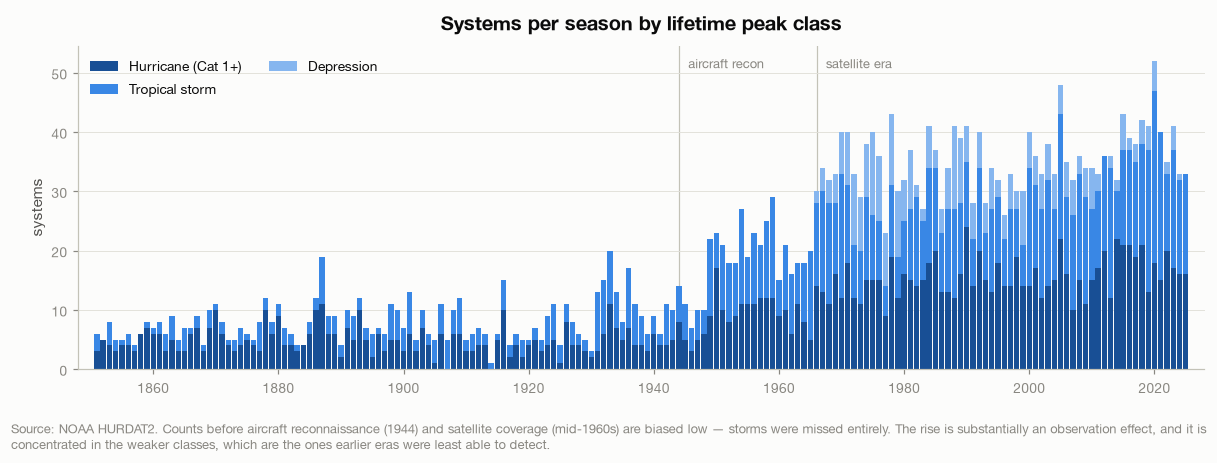

In [17]:
# Storms per season by lifetime class. Basin composition is reported in the
# table rather than the figure, so the bars can carry the class breakdown.
per_season = (storms.groupby(["season", "event_class"], observed=False).size()
              .unstack(fill_value=0).reindex(columns=CLASS_ORDER, fill_value=0))
display(pd.concat([
    per_season.tail(6),
    storms.groupby(["basin", "event_class"], observed=False).size()
          .unstack(fill_value=0).reindex(columns=CLASS_ORDER, fill_value=0),
], keys=["recent seasons", "all seasons by basin"]))

fig, ax = plt.subplots(figsize=(11, 3.8))

# Stacked: the classes partition the same total, so stack height is the
# meaningful "systems this season" number.
bottom = np.zeros(len(per_season))
for cls in CLASS_ORDER:
    if per_season[cls].sum() == 0:
        continue
    ax.bar(per_season.index, per_season[cls], bottom=bottom, width=0.85,
           color=CLASS_COLOR[cls], label=cls, linewidth=0)
    bottom += per_season[cls].values

ax.set_title("Systems per season by lifetime peak class")
ax.set_ylabel("systems")
ax.set_xlim(1848, 2028)
class_legend(ax, per_season.columns[per_season.sum() > 0], loc="upper left", ncols=2)
tidy(ax)

# The two regime shifts that govern how these counts should be read.
for year, label in [(1944, "aircraft recon"), (1966, "satellite era")]:
    ax.axvline(year, color=AXIS, linewidth=0.8, zorder=0)
    ax.text(year + 1.5, ax.get_ylim()[1] * 0.93, label,
            fontsize=8.5, color=INK_MUTED)

caption(fig, "Source: NOAA HURDAT2. Counts before aircraft reconnaissance (1944) and "
             "satellite coverage (mid-1960s) are biased low — storms were missed "
             "entirely. The rise is substantially an observation effect, and it is "
             "concentrated in the weaker classes, which are the ones earlier eras "
             "were least able to detect.")
plt.tight_layout()
plt.show()

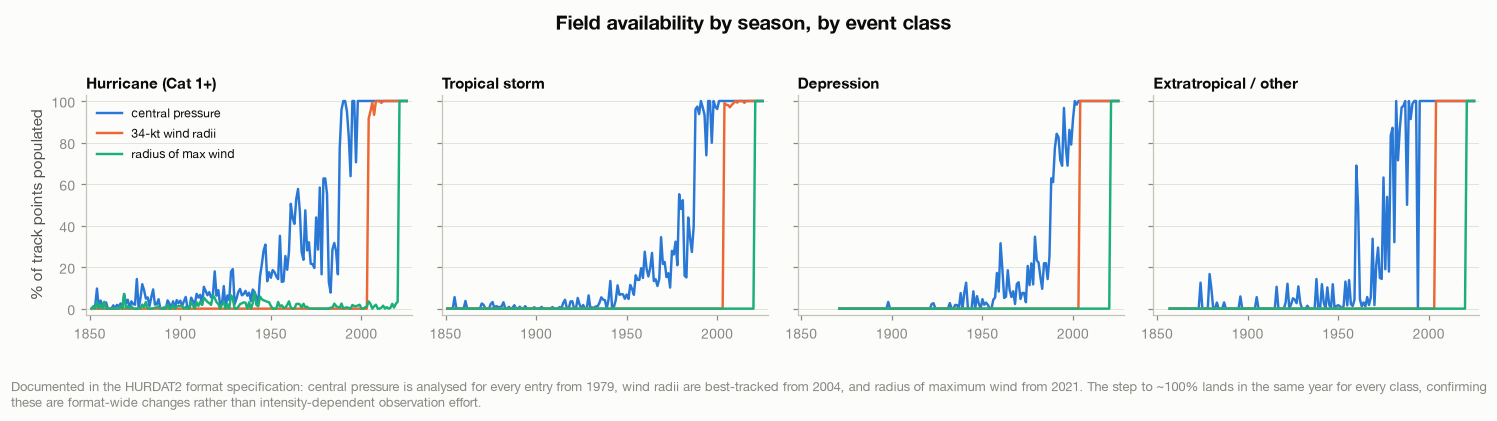

In [18]:
# When does each field actually start? Anything computed on a field before its
# start year is computed on nulls. Faceted by class, because observation effort
# is not uniform across intensity -- hurricanes are better instrumented.
FIELDS = [("central pressure", "min_pressure_mb"),
          ("34-kt wind radii", "r34_ne_nm"),
          ("radius of max wind", "radius_max_wind_nm")]

panels = [c for c in CLASS_ORDER[:4]]
fig, axes = plt.subplots(1, 4, figsize=(13.5, 3.1), sharex=True, sharey=True)

for ax, cls in zip(axes, panels):
    subset = points[points.event_class == cls]
    for (label, col), color in zip(FIELDS, [BLUE, ORANGE, AQUA]):
        series = subset.groupby("season")[col].apply(lambda s: s.notna().mean())
        ax.plot(series.index, series.values * 100, color=color, linewidth=1.6,
                label=label)
    ax.set_title(cls, fontsize=10, loc="left", pad=4)
    ax.set_ylim(-3, 103)
    ax.set_xlim(1848, 2028)
    tidy(ax)

axes[0].set_ylabel("% of track points populated")
axes[0].legend(loc="upper left", fontsize=8)

fig.suptitle("Field availability by season, by event class",
             fontsize=13, fontweight="bold", color=INK, x=0.5, y=1.02)
caption(fig, "Documented in the HURDAT2 format specification: central pressure is "
             "analysed for every entry from 1979, wind radii are best-tracked from "
             "2004, and radius of maximum wind from 2021. The step to ~100% lands in "
             "the same year for every class, confirming these are format-wide "
             "changes rather than intensity-dependent observation effort.", y=-0.06)
plt.tight_layout()
plt.show()

## 4. Intensity distributions

event_class,Hurricane (Cat 1+),Tropical storm,Depression,Extratropical / other,Unclassified (no wind)
ss_category,,,,,
UNK,0,0,0,0,57
TD,0,0,18039,6663,0
TS,0,33374,0,5005,0
1,12728,0,0,646,0
2,5596,0,0,39,0
3,3222,0,0,2,0
4,1974,0,0,0,0
5,286,0,0,0,0


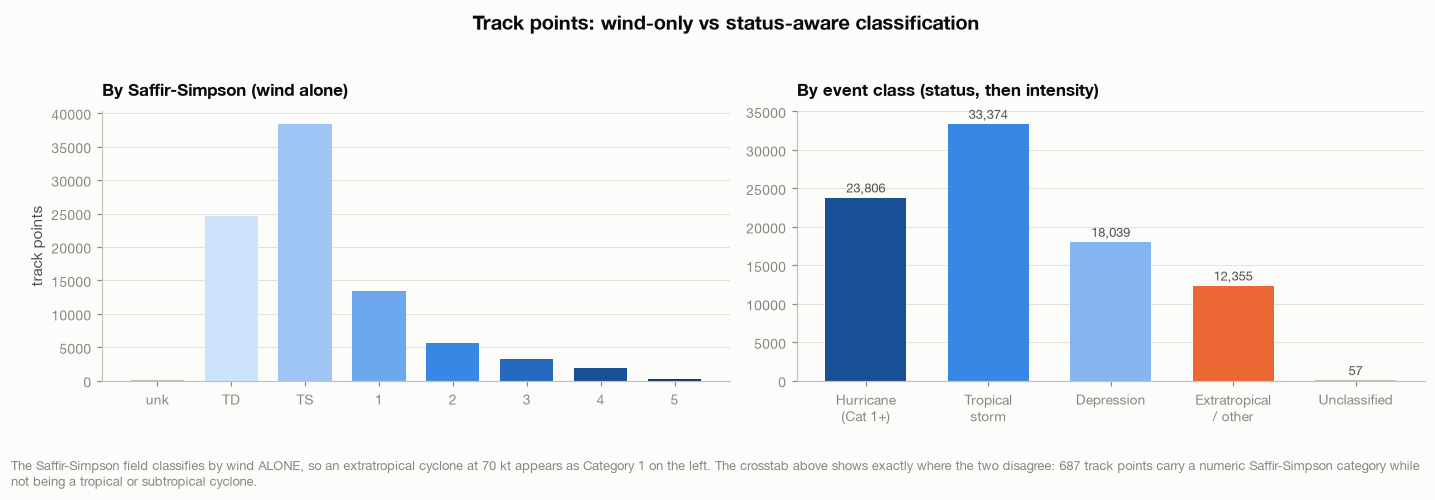

In [19]:
# Two views of the same track points, side by side: the wind-only Saffir-Simpson
# label the database stores, and the status-aware event class this notebook uses.
# The difference between them is the whole point of classifying by status first.
ss_order = ["UNK", "TD", "TS", "1", "2", "3", "4", "5"]
ss_counts = points.ss_category.value_counts().reindex(ss_order).fillna(0).astype(int)
cls_counts = points.event_class.value_counts().reindex(CLASS_ORDER).fillna(0).astype(int)

comparison = pd.crosstab(points.ss_category, points.event_class).reindex(
    index=ss_order, columns=CLASS_ORDER).fillna(0).astype(int)
display(comparison)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 3.8))

# LEFT: Saffir-Simpson, wind alone. Ordered, so a single-hue ordinal ramp.
ramp = ["#c3c2b7"] + SEQ_BLUE
bars = ax1.bar(range(len(ss_order)), ss_counts.values,
               color=ramp[:len(ss_order)], width=0.72, linewidth=0)
ax1.set_xticks(range(len(ss_order)))
ax1.set_xticklabels(["unk", "TD", "TS", "1", "2", "3", "4", "5"])
ax1.set_title("By Saffir-Simpson (wind alone)", fontsize=11, loc="left")
ax1.set_ylabel("track points")
tidy(ax1)

# RIGHT: the status-aware event class used throughout this notebook.
present = [c for c in CLASS_ORDER if cls_counts[c] > 0]
ax2.bar(range(len(present)), [cls_counts[c] for c in present],
        color=[CLASS_COLOR[c] for c in present], width=0.66, linewidth=0)
ax2.set_xticks(range(len(present)))
ax2.set_xticklabels(["Hurricane\n(Cat 1+)", "Tropical\nstorm", "Depression",
                     "Extratropical\n/ other", "Unclassified"][:len(present)],
                    fontsize=9)
ax2.set_title("By event class (status, then intensity)", fontsize=11, loc="left")
tidy(ax2)
for i, c in enumerate(present):
    ax2.text(i, cls_counts[c] + cls_counts.max() * 0.02, f"{cls_counts[c]:,}",
             ha="center", fontsize=8.5, color=INK_SECOND)

fig.suptitle("Track points: wind-only vs status-aware classification",
             fontsize=13, fontweight="bold", color=INK, x=0.5, y=1.03)
caption(fig,
    "The Saffir-Simpson field classifies by wind ALONE, so an extratropical cyclone "
    "at 70 kt appears as Category 1 on the left. The crosstab above shows exactly "
    "where the two disagree: %d track points carry a numeric Saffir-Simpson category "
    "while not being a tropical or subtropical cyclone."
    % comparison.loc[["1", "2", "3", "4", "5"], CLS_EXTRA].sum(), y=-0.04)
plt.tight_layout()
plt.show()

,n,pearson_r,wind_kt_median,pressure_mb_median
class,,,,
Hurricane (Cat 1+),11238,-0.923,85.0,973.0
Tropical storm,15817,-0.732,45.0,1000.0
Depression,8323,-0.286,30.0,1007.0
Extratropical / other,8513,-0.830,25.0,1007.0


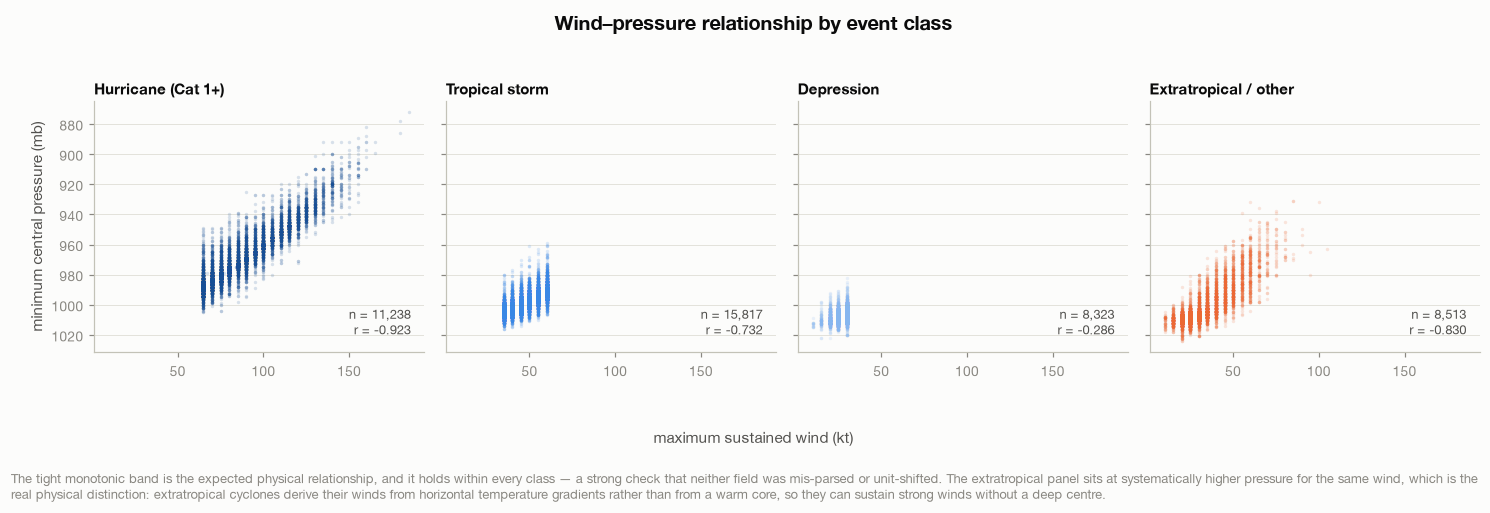

In [20]:
# Wind-pressure relationship. These are physically coupled, so the scatter is a
# strong check that neither field was mis-parsed or unit-shifted.
wp = points[["max_wind_kt", "min_pressure_mb", "event_class"]].dropna(
    subset=["max_wind_kt", "min_pressure_mb"])

# Faceted rather than colour-coded: overlapping scatter clouds cannot be
# separated reliably by hue, and a dense scatter is exactly the chart form where
# more than about three colours stops being readable.
panels = [c for c in CLASS_ORDER[:4]]
fig, axes = plt.subplots(1, 4, figsize=(13.5, 3.7), sharex=True, sharey=True)

stats = []
for ax, cls in zip(axes, panels):
    sub = wp[wp.event_class == cls]
    ax.scatter(sub.max_wind_kt, sub.min_pressure_mb,
               s=5, color=CLASS_COLOR[cls], alpha=0.16, linewidth=0)
    r = sub.max_wind_kt.corr(sub.min_pressure_mb) if len(sub) > 2 else np.nan
    stats.append({"class": cls, "n": len(sub), "pearson_r": round(r, 3),
                  "wind_kt_median": sub.max_wind_kt.median(),
                  "pressure_mb_median": sub.min_pressure_mb.median()})
    ax.set_title(cls, fontsize=10, loc="left", pad=4)
    ax.text(0.96, 0.06, f"n = {len(sub):,}\nr = {r:.3f}", transform=ax.transAxes,
            ha="right", va="bottom", fontsize=8.5, color=INK_SECOND)
    tidy(ax)

axes[0].set_ylabel("minimum central pressure (mb)")
axes[0].invert_yaxis()      # lower pressure = stronger, so it reads upward
fig.supxlabel("maximum sustained wind (kt)", fontsize=10, color=INK_SECOND, y=-0.04)

display(pd.DataFrame(stats).set_index("class"))

fig.suptitle("Wind–pressure relationship by event class",
             fontsize=13, fontweight="bold", color=INK, x=0.5, y=1.03)
caption(fig,
    "The tight monotonic band is the expected physical relationship, and it holds "
    "within every class — a strong check that neither field was mis-parsed or "
    "unit-shifted. The extratropical panel sits at systematically higher pressure "
    "for the same wind, which is the real physical distinction: extratropical "
    "cyclones derive their winds from horizontal temperature gradients rather than "
    "from a warm core, so they can sustain strong winds without a deep centre.",
    y=-0.10)
plt.tight_layout()
plt.show()

## 5. Landfalls nationally, by year

The headline series. Scope is stated explicitly so the number is unambiguous:
**countable landfalls** (`is_landfall`), in the **United States**, restricted to
**continental** coastal states, at **all intensities**.

That last point matters. The database records every crossing regardless of
strength, so most continental U.S. landfalls are *not* hurricanes — a chart of
"landfalls" that quietly mixes 45 kt tropical storms with Category 5s invites
being misread as a hurricane count. The series below is therefore split by
event class, and post-tropical systems are shown separately rather than folded
in. `python -m hutrackdb qa` compares the hurricane-only subset against
NOAA's All U.S. Hurricanes list, which counts hurricanes exclusively.

In [21]:
# Continental US coastal states. Hawaii, Alaska, Puerto Rico and the Virgin
# Islands are US landfalls but are NOT continental, so they are excluded here
# and reported separately -- `is_us_landfall` alone would silently include them.
CONUS_STATES = [
    "Texas", "Louisiana", "Mississippi", "Alabama", "Florida", "Georgia",
    "South Carolina", "North Carolina", "Virginia", "Maryland", "Delaware",
    "New Jersey", "New York", "Pennsylvania", "Connecticut", "Rhode Island",
    "Massachusetts", "New Hampshire", "Maine",
]

lf = landfalls.merge(storms[["storm_id", "season", "name"]], on="storm_id")

us_all = lf[lf.is_landfall & lf.is_us_landfall]
conus  = us_all[us_all.landfall_admin1.isin(CONUS_STATES)].copy()

print(f"countable US landfalls        : {len(us_all):,}")
print(f"  of which continental (CONUS) : {len(conus):,}")
print(f"  non-continental (HI/AK/PR/VI): {len(us_all) - len(conus):,}")
print(f"distinct storms making a CONUS landfall: {conus.storm_id.nunique():,}")
print(f"seasons covered: {conus.season.min()}–{conus.season.max()}")

countable US landfalls        : 1,568
  of which continental (CONUS) : 1,548
  non-continental (HI/AK/PR/VI): 20
distinct storms making a CONUS landfall: 645
seasons covered: 1851–2025


In [22]:
# INTENSITY SCOPE. The landfalls table records every crossing regardless of
# intensity, because config sets landfall.min_wind_kt = null so that filtering
# stays a downstream choice. Most CONUS landfalls are therefore NOT hurricanes:
composition = conus.exact_ss_category.value_counts()
hurricane_mask = conus.exact_wind_kt >= 64          # NHC hurricane threshold
print("intensity composition of continental U.S. landfalls:")
for label in ["5", "4", "3", "2", "1", "TS", "TD", "UNK"]:
    if label in composition:
        print(f"  {label:>4s}  {composition[label]:>5,}")
print(f"\nhurricane-intensity (>= 64 kt): {hurricane_mask.sum():,} of {len(conus):,} "
      f"({hurricane_mask.mean():.0%})")

# Worked example of why the distinction matters. The most recent season's only
# landfall is sub-hurricane, so it appears in this table but is correctly absent
# from NOAA's hurricane-only reference list (which records 2025 as "None").
latest = conus[conus.season == conus.season.max()]
display(latest[["name", "exact_time", "landfall_admin1", "exact_wind_kt",
                "exact_ss_category", "status_at_landfall", "detection_method"]])

intensity composition of continental U.S. landfalls:
     5      8
     4     41
     3    107
     2    141
     1    274
    TS    763
    TD    196
   UNK     18

hurricane-intensity (>= 64 kt): 571 of 1,548 (37%)


,name,exact_time,landfall_admin1,exact_wind_kt,exact_ss_category,status_at_landfall,detection_method
6118,CHANTAL,2025-07-06 07:53:08.571429+00:00,South Carolina,45.0,TS,TS,native_confirmed


In [23]:
# Split the series by event class rather than reporting a single total: a chart
# of "landfalls" that silently mixes 45 kt tropical storms, post-tropical
# systems and Category 5s invites being read as a hurricane count.
years = range(conus.season.min(), conus.season.max() + 1)
national = (conus.groupby(["season", "event_class"], observed=False).size()
            .unstack(fill_value=0)
            .reindex(index=years, fill_value=0)
            .reindex(columns=CLASS_ORDER, fill_value=0))

national["all_landfalls"] = national[CLASS_ORDER].sum(axis=1)

# ---------------------------------------------------------------------------
# SMOOTHING WINDOW.
#
# Trends below are centred rolling means, not fitted regression lines. A fitted
# slope over this record would imply a physical trend the data cannot support:
# pre-1944 counts are biased low by storms that were missed outright, so any
# regression is measuring observing capability as much as storm behaviour. A
# rolling mean is descriptive -- it smooths, it does not extrapolate or claim
# a rate of change.
#
# NOTE: the 10-season window is an analyst choice, not a sourced value. It is
# declared here rather than buried so it can be changed in one place and so its
# status is visible. A wider window flattens the interdecadal swings; a
# narrower one lets single seasons dominate.
SMOOTHING_SEASONS = 10
MIN_SEASONS_FOR_MEAN = 6      # seasons required before a mean is emitted

def smoothed(series):
    """Centred rolling mean over SMOOTHING_SEASONS."""
    return series.rolling(SMOOTHING_SEASONS, center=True,
                          min_periods=MIN_SEASONS_FOR_MEAN).mean()

national["all_10yr_mean"] = smoothed(national.all_landfalls)
for cls in CLASS_ORDER:
    national[f"{cls} — trend"] = smoothed(national[cls])

# Table view: the figure below is drawn from exactly this.
display(national.tail(12))
print(f"\nmean landfalls/yr: {national.all_landfalls.mean():.2f}   "
      f"max: {national.all_landfalls.max()} "
      f"({national.all_landfalls.idxmax()})   "
      f"seasons with none: {(national.all_landfalls == 0).sum()}")
print("\ntotals by class:")
for c in CLASS_ORDER:
    if national[c].sum():
        print(f"  {c:24s} {national[c].sum():>5,}  "
              f"({national[c].sum() / national.all_landfalls.sum():.0%})")

event_class,Hurricane (Cat 1+),Tropical storm,Depression,Extratropical / other,Unclassified (no wind),all_landfalls,all_10yr_mean,Hurricane (Cat 1+) — trend,Tropical storm — trend,Depression — trend,Extratropical / other — trend,Unclassified (no wind) — trend
season,,,,,,,,,,,,
2014,3,0,0,0,0,3,7.500000,1.900000,2.900000,0.900000,1.800000,0.0
2015,0,3,2,1,0,6,7.800000,2.100000,2.900000,0.900000,1.900000,0.0
2016,2,2,3,3,0,10,9.100000,3.000000,3.600000,0.900000,1.600000,0.0
2017,7,5,1,0,0,13,10.200000,3.100000,4.300000,0.800000,2.000000,0.0
2018,3,6,0,0,0,9,10.800000,3.600000,4.600000,0.800000,1.800000,0.0
2019,2,1,0,3,0,6,10.800000,3.700000,4.900000,0.800000,1.400000,0.0
2020,9,9,1,1,0,20,11.400000,4.200000,5.000000,0.800000,1.400000,0.0
2021,3,14,1,4,0,22,10.900000,4.200000,4.800000,0.600000,1.300000,0.0
2022,7,5,0,2,0,14,11.000000,4.444444,5.111111,0.333333,1.111111,0.0



mean landfalls/yr: 8.85   max: 30 (1999)   seasons with none: 3

totals by class:
  Hurricane (Cat 1+)         559  (36%)
  Tropical storm             654  (42%)
  Depression                 156  (10%)
  Extratropical / other      161  (10%)
  Unclassified (no wind)      18  (1%)


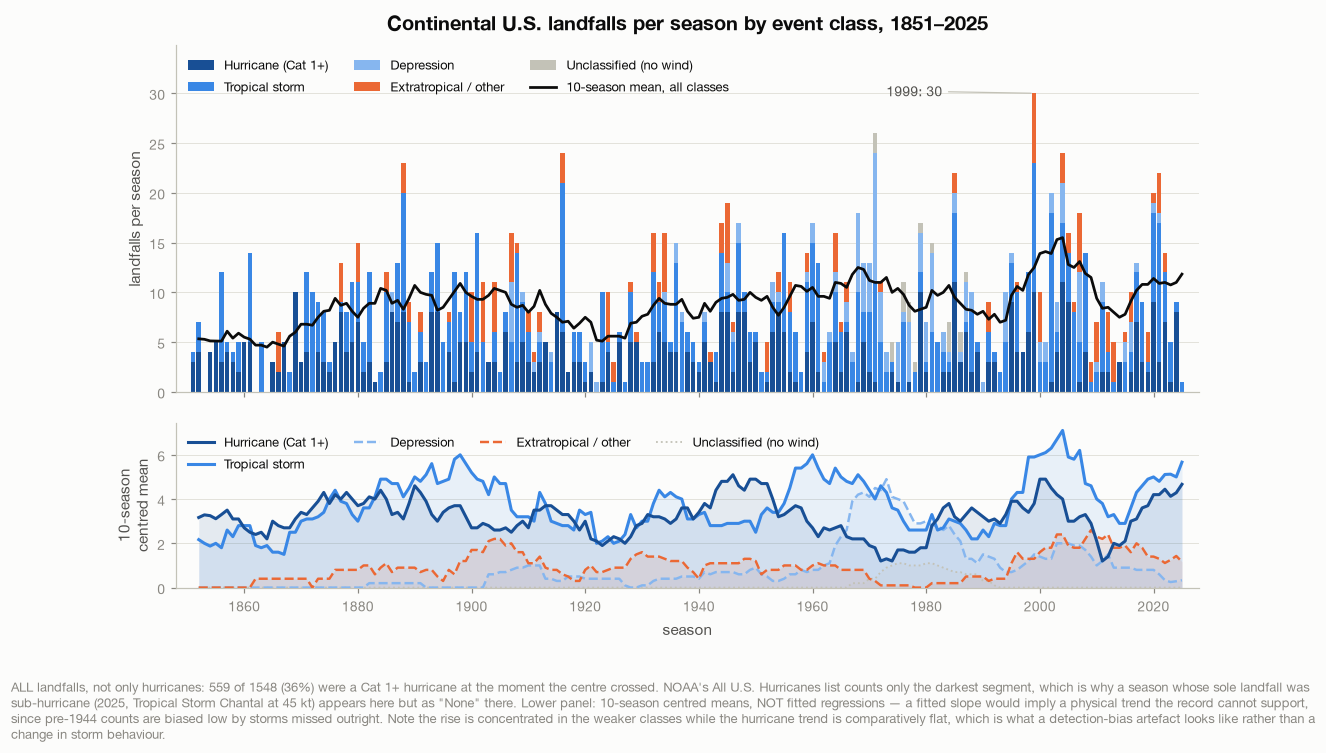

In [24]:
# Two panels sharing one x-axis rather than one crowded panel: stacked bars
# carry composition, and the per-class trends get their own space underneath.
# Overlaying five lines on a four-way stack was unreadable.
fig, (ax, axt) = plt.subplots(
    2, 1, figsize=(12, 6.4), sharex=True,
    gridspec_kw={"height_ratios": [2.1, 1], "hspace": 0.12})

# --- TOP: annual composition -------------------------------------------------
# Stacked by event class, strongest at the base. The three tropical classes use
# a single-hue ordinal ramp (darker = stronger) because they are ORDERED;
# extratropical takes a separate hue because it is a different kind of system,
# not another intensity step.
bottom = np.zeros(len(national))
for cls in CLASS_ORDER:
    if national[cls].sum() == 0:
        continue
    ax.bar(national.index, national[cls], bottom=bottom, width=0.8,
           color=CLASS_COLOR[cls], linewidth=0, label=cls)
    bottom += national[cls].values

ax.plot(national.index, national.all_10yr_mean,
        color="#0b0b0b", linewidth=1.8, label="all classes")

ax.set_title("Continental U.S. landfalls per season by event class, 1851–2025")
ax.set_ylabel("landfalls per season")
ax.set_xlim(1848, 2028)
ax.set_ylim(0, national.all_landfalls.max() * 1.16)
tidy(ax)

from matplotlib.patches import Patch
from matplotlib.lines import Line2D
handles = [Patch(facecolor=CLASS_COLOR[c], label=c)
           for c in CLASS_ORDER if national[c].sum() > 0]
handles.append(Line2D([0], [0], color="#0b0b0b", linewidth=1.8,
                      label=f"{SMOOTHING_SEASONS}-season mean, all classes"))
ax.legend(handles=handles, loc="upper left", ncols=3, fontsize=8.5)

# Direct-label only the record season -- selective, not one label per bar.
peak_year = int(national.all_landfalls.idxmax())
peak_val = int(national.all_landfalls.max())
ax.annotate(f"{peak_year}: {peak_val}",
            xy=(peak_year, peak_val), xytext=(peak_year - 26, peak_val * 0.99),
            fontsize=9, color=INK_SECOND,
            arrowprops=dict(arrowstyle="-", color=AXIS, linewidth=0.8))

# --- BOTTOM: one trend per class --------------------------------------------
# Hurricane and tropical storm carry solid lines; the two smaller classes are
# dashed so they stay separable where all four converge near the axis.
TREND_STYLE = {
    CLS_HURRICANE:  dict(linestyle="-",  linewidth=2.0, zorder=5),
    CLS_TSTORM:     dict(linestyle="-",  linewidth=2.0, zorder=4),
    CLS_DEPRESSION: dict(linestyle="--", linewidth=1.6, zorder=3),
    CLS_EXTRA:      dict(linestyle="--", linewidth=1.6, zorder=3),
}
for cls in CLASS_ORDER:
    col = f"{cls} — trend"
    if col not in national or national[cls].sum() == 0:
        continue
    style = TREND_STYLE.get(cls, dict(linestyle=":", linewidth=1.2))
    # A faint band under each line gives the eye a shape to follow where the
    # lines bunch together, without adding another colour.
    axt.fill_between(national.index, 0, national[col],
                     color=CLASS_COLOR[cls], alpha=0.10, linewidth=0)
    axt.plot(national.index, national[col], color=CLASS_COLOR[cls],
             label=cls, **style)

axt.set_ylabel(f"{SMOOTHING_SEASONS}-season\ncentred mean")
axt.set_xlabel("season")
axt.set_ylim(0, None)
tidy(axt)
axt.legend(loc="upper left", ncols=4, fontsize=8.5)

caption(fig,
    "ALL landfalls, not only hurricanes: %d of %d (%.0f%%) were a Cat 1+ hurricane at "
    "the moment the centre crossed. NOAA's All U.S. Hurricanes list counts only the "
    "darkest segment, which is why a season whose sole landfall was sub-hurricane "
    "(2025, Tropical Storm Chantal at 45 kt) appears here but as \"None\" there. "
    "Lower panel: %d-season centred means, NOT fitted regressions — a fitted slope "
    "would imply a physical trend the record cannot support, since pre-1944 counts "
    "are biased low by storms missed outright. Note the rise is concentrated in the "
    "weaker classes while the hurricane trend is comparatively flat, which is what a "
    "detection-bias artefact looks like rather than a change in storm behaviour."
    % (national[CLS_HURRICANE].sum(), national.all_landfalls.sum(),
       100 * national[CLS_HURRICANE].sum() / national.all_landfalls.sum(),
       SMOOTHING_SEASONS), y=-0.02)
# No tight_layout here: the panel spacing is already set by the gridspec hspace
# above, and tight_layout cannot reconcile the two -- it warns and may override
# the ratio that keeps the trend panel readable.
plt.show()

## 6. Landfalls by state — small multiples

One panel per coastal state, on a **shared y-axis** so panels are directly
comparable — that comparability is the entire point of small multiples. Panels
are ordered by total landfalls, so the ranking is readable at a glance.

In [25]:
# Long-form state-by-season matrix, zero-filled so quiet seasons show as gaps
# rather than vanishing from the series.
years = range(conus.season.min(), conus.season.max() + 1)
by_state = (conus.groupby(["landfall_admin1", "season"]).size()
            .unstack(fill_value=0).reindex(columns=years, fill_value=0))

state_totals = by_state.sum(axis=1).sort_values(ascending=False)
by_state = by_state.loc[state_totals.index]

# Per state, per season, per class -- the array the stacked panels are drawn
# from. Zero-filled so quiet seasons show as gaps rather than vanishing.
by_state_class = {
    cls: (conus[conus.event_class == cls]
          .groupby(["landfall_admin1", "season"]).size()
          .unstack(fill_value=0)
          .reindex(index=state_totals.index, columns=years, fill_value=0))
    for cls in CLASS_ORDER
}

# Class composition per state -- the table view for the figure below, and the
# clearest way to compare composition across states.
composition = pd.DataFrame(
    {cls: frame.sum(axis=1) for cls, frame in by_state_class.items()}
).reindex(state_totals.index)
composition["total"] = composition.sum(axis=1)
composition["hurricane_%"] = (100 * composition[CLS_HURRICANE]
                              / composition.total).round(1)
display(composition)
print(f"{len(by_state)} states with at least one recorded landfall")

,Hurricane (Cat 1+),Tropical storm,Depression,Extratropical / other,Unclassified (no wind),total,hurricane_%
landfall_admin1,,,,,,,
Florida,203,223,68,15,3,512,39.6
North Carolina,74,96,13,32,1,216,34.3
Louisiana,85,79,23,5,3,195,43.6
Texas,85,65,21,0,4,175,48.6
New York,19,37,2,15,0,73,26.0
Maine,2,14,0,40,0,56,3.6
South Carolina,31,15,7,1,2,56,55.4
Mississippi,13,18,3,2,5,41,31.7
Georgia,9,24,7,0,0,40,22.5


16 states with at least one recorded landfall


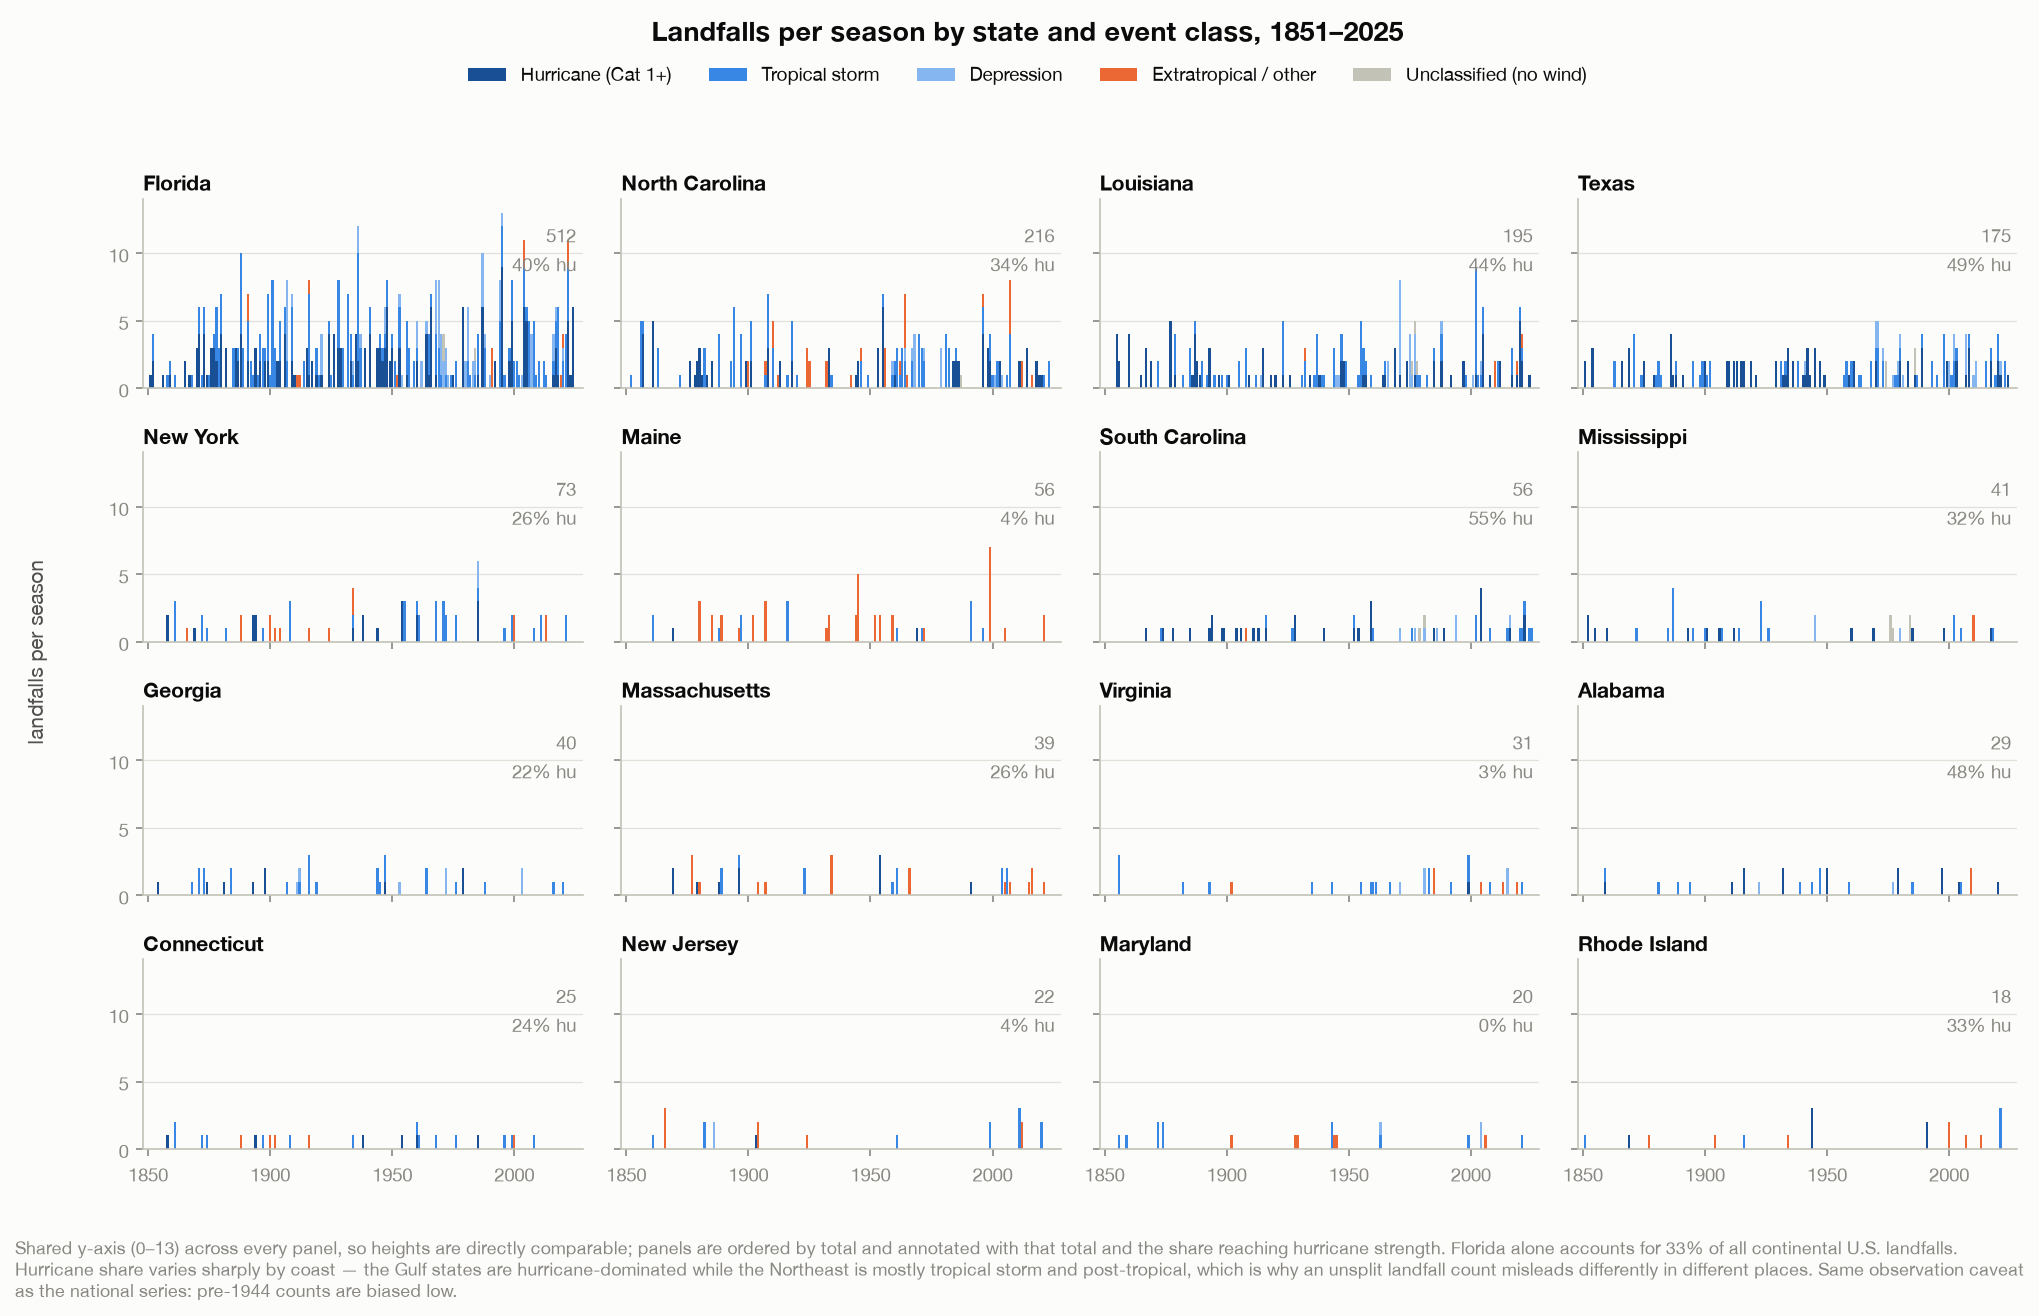

In [26]:
n = len(by_state)
ncols = 4
nrows = int(np.ceil(n / ncols))
ymax = int(by_state.values.max())

# Higher DPI than the notebook default: at 175 seasons across a narrow panel a
# single year is under two pixels, and antialiasing turns isolated tall bars
# into grey smears at the default resolution.
fig, axes = plt.subplots(nrows, ncols, figsize=(13.5, 1.95 * nrows),
                         sharex=True, sharey=True, dpi=150)
axes = axes.ravel()

for ax, state in zip(axes, by_state.index):
    # Stacked by class within each season. Bars are width 0.9 rather than 1.0 so
    # adjacent seasons keep a surface gap instead of fusing into a solid block.
    bottom = np.zeros(len(years))
    for cls in CLASS_ORDER:
        values = by_state_class[cls].loc[state].values
        if values.sum() == 0:
            continue
        ax.bar(list(years), values, bottom=bottom, width=0.9,
               color=CLASS_COLOR[cls], linewidth=0, label=cls)
        bottom += values

    ax.set_title(state, fontsize=10, loc="left", pad=4)
    # Panel total and hurricane share, so short bars stay quantitatively
    # readable and the composition is legible even where the stack is 1 px tall.
    ax.text(0.985, 0.88,
            f"{int(state_totals[state]):,}\n"
            f"{composition.loc[state, 'hurricane_%']:.0f}% hu",
            transform=ax.transAxes, ha="right", va="top",
            fontsize=9, color=INK_MUTED, linespacing=1.3)

    ax.set_xlim(1848, 2028)
    ax.set_ylim(0, ymax * 1.08)
    ax.set_yticks([0, 5, 10])
    tidy(ax)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(AXIS)

# Blank out unused grid positions rather than leaving empty axes.
for ax in axes[n:]:
    ax.set_visible(False)

# Title on its own line, legend centred beneath it -- anchoring the legend to
# the top-right put it straight through the title text.
fig.suptitle("Landfalls per season by state and event class, 1851–2025",
             fontsize=13, fontweight="bold", color=INK, x=0.5, y=1.045)
fig.supylabel("landfalls per season", fontsize=10, color=INK_SECOND, x=0.004)

# One legend for the whole figure -- repeating it in all 16 panels would be noise.
class_legend(fig, [c for c in CLASS_ORDER if composition[c].sum() > 0],
             loc="upper center", ncols=5, bbox_to_anchor=(0.5, 1.018), fontsize=9)

caption(fig,
    "Shared y-axis (0–%d) across every panel, so heights are directly comparable; "
    "panels are ordered by total and annotated with that total and the share reaching "
    "hurricane strength. Florida alone accounts for %.0f%% of all continental U.S. "
    "landfalls. Hurricane share varies sharply by coast — the Gulf states are "
    "hurricane-dominated while the Northeast is mostly tropical storm and "
    "post-tropical, which is why an unsplit landfall count misleads differently in "
    "different places. Same observation caveat as the national series: pre-1944 "
    "counts are biased low."
    % (ymax, 100 * state_totals.iloc[0] / state_totals.sum()), y=0.0)
plt.tight_layout(rect=[0.012, 0.025, 1, 0.978])
plt.show()

### Per-state trends by class

The panels above answer "what happened in each season". This companion answers
"where is each class heading", which the raw bars cannot show at 16 panels'
worth of one- and two-count seasons.

It is a **separate figure rather than an overlay**: four trend lines drawn on
top of a four-way stack was unreadable, and the two questions want different
y-scales — annual counts reach 13, smoothed means barely exceed 4.

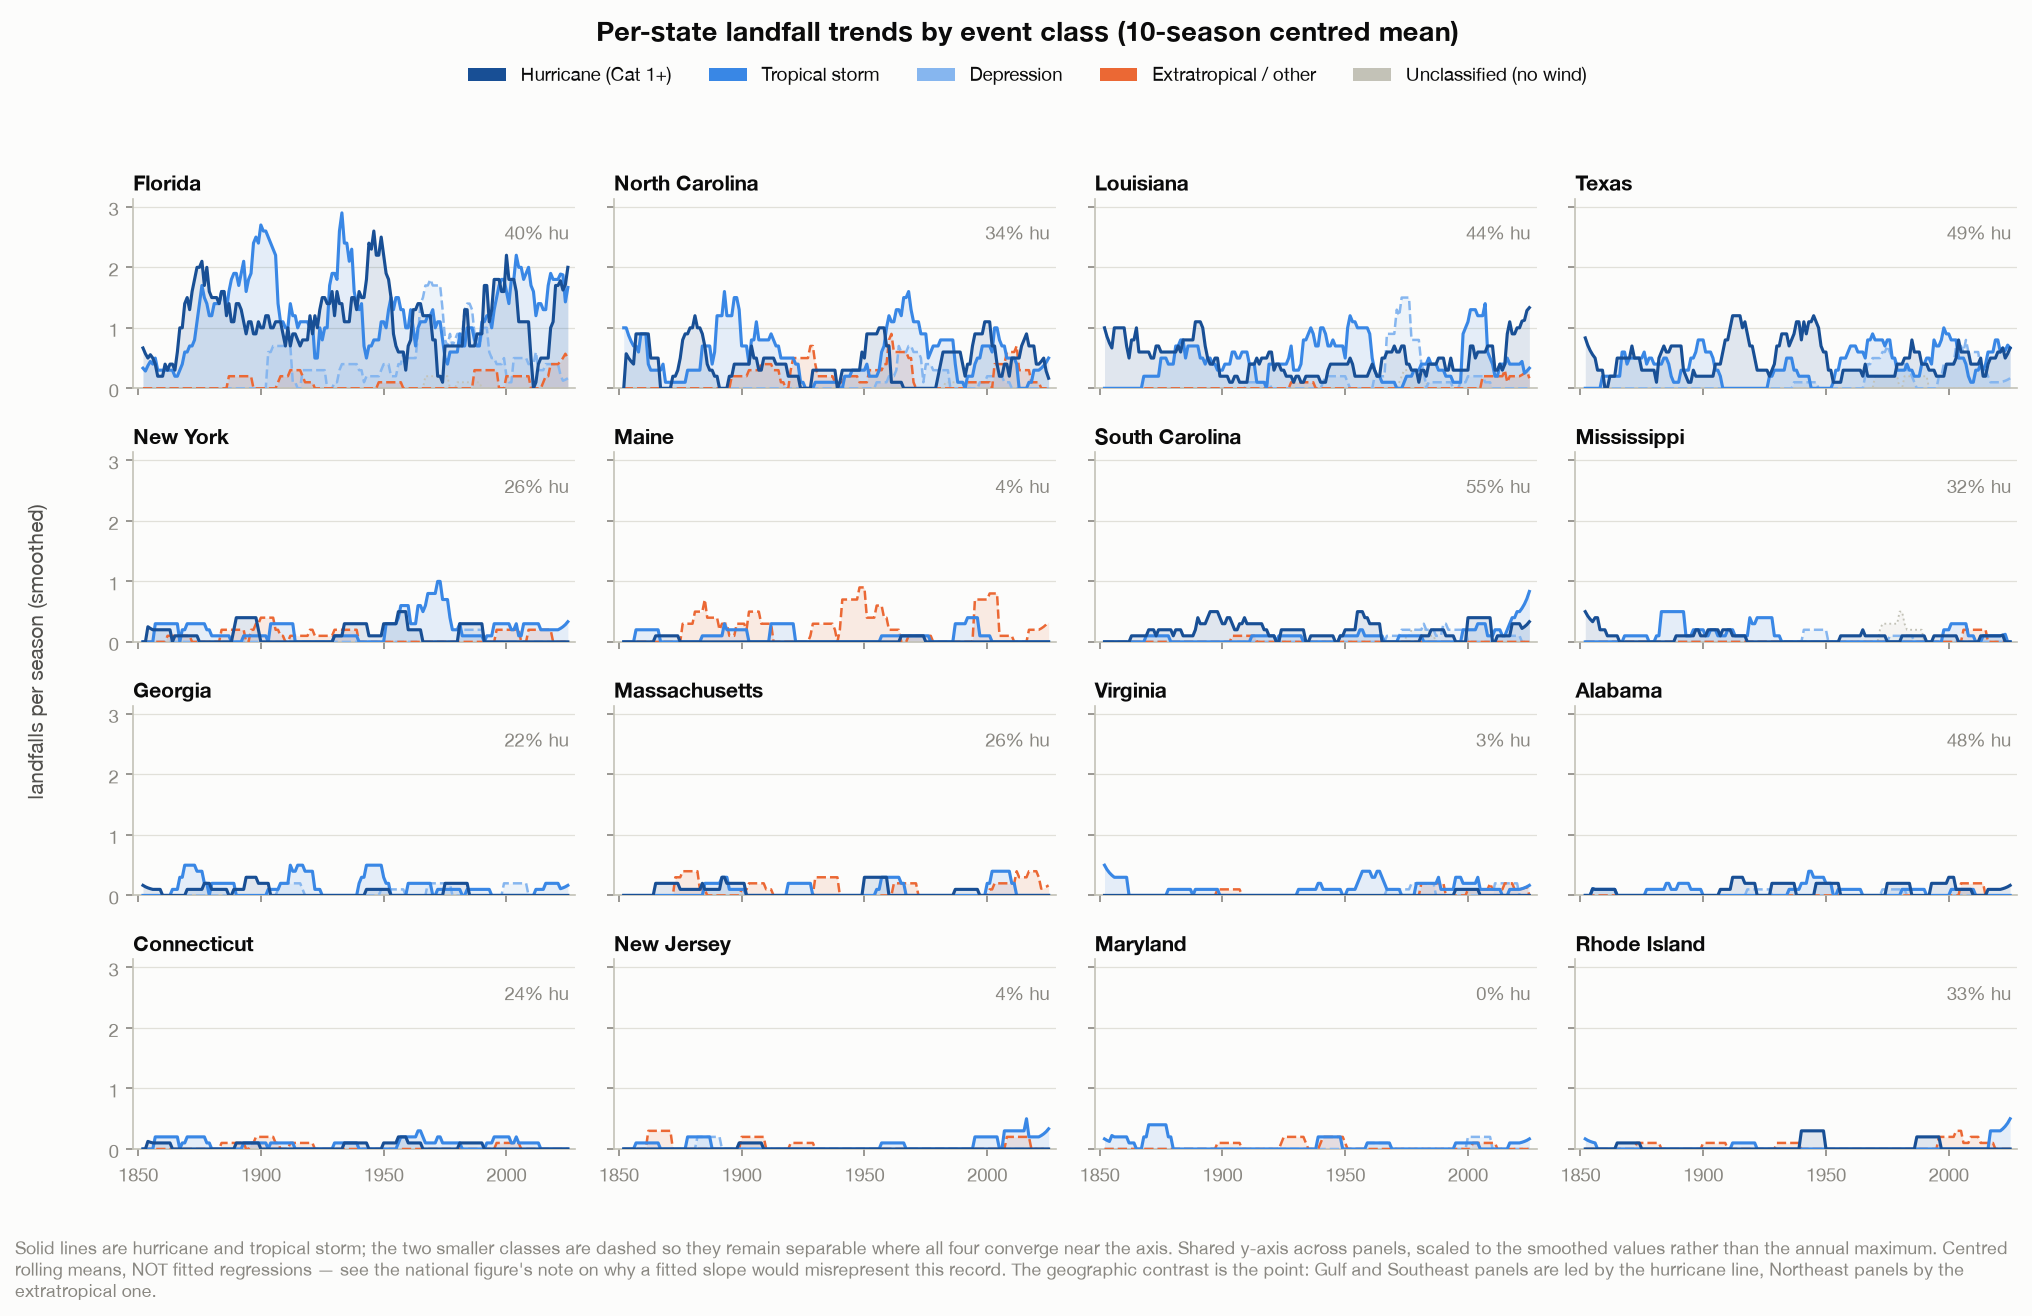

In [27]:
# Smoothed per-class series for every state.
state_trend = {
    cls: by_state_class[cls].apply(smoothed, axis=1)
    for cls in CLASS_ORDER
}

# Scale to the trends, not to the raw annual maximum. On the 0–13 annual scale
# every trend would be squashed into the bottom eighth of its panel.
# nanmax, because a centred rolling mean is undefined at both ends of the record.
tmax = float(max(np.nanmax(frame.to_numpy()) for frame in state_trend.values()))

fig, axes = plt.subplots(nrows, ncols, figsize=(13.5, 1.95 * nrows),
                         sharex=True, sharey=True, dpi=150)
axes = axes.ravel()

for ax, state in zip(axes, by_state.index):
    for cls in CLASS_ORDER:
        if composition.loc[state, cls] == 0:
            continue
        series = state_trend[cls].loc[state]
        style = TREND_STYLE.get(cls, dict(linestyle=":", linewidth=1.2))
        # Faint fill under each line so classes stay separable where they
        # converge near zero, without introducing another colour.
        ax.fill_between(series.index, 0, series.values,
                        color=CLASS_COLOR[cls], alpha=0.12, linewidth=0)
        ax.plot(series.index, series.values, color=CLASS_COLOR[cls],
                **{**style, "linewidth": style["linewidth"] * 0.75})

    ax.set_title(state, fontsize=10, loc="left", pad=4)
    ax.text(0.985, 0.88, f"{composition.loc[state, 'hurricane_%']:.0f}% hu",
            transform=ax.transAxes, ha="right", va="top",
            fontsize=9, color=INK_MUTED)
    ax.set_xlim(1848, 2028)
    ax.set_ylim(0, tmax * 1.08)
    tidy(ax)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(AXIS)

for ax in axes[len(by_state):]:
    ax.set_visible(False)

fig.suptitle(f"Per-state landfall trends by event class "
             f"({SMOOTHING_SEASONS}-season centred mean)",
             fontsize=13, fontweight="bold", color=INK, x=0.5, y=1.045)
fig.supylabel("landfalls per season (smoothed)", fontsize=10,
              color=INK_SECOND, x=0.004)
class_legend(fig, [c for c in CLASS_ORDER if composition[c].sum() > 0],
             loc="upper center", ncols=5, bbox_to_anchor=(0.5, 1.018), fontsize=9)

caption(fig,
    "Solid lines are hurricane and tropical storm; the two smaller classes are "
    "dashed so they remain separable where all four converge near the axis. Shared "
    "y-axis across panels, scaled to the smoothed values rather than the annual "
    "maximum. Centred rolling means, NOT fitted regressions — see the national "
    "figure's note on why a fitted slope would misrepresent this record. The "
    "geographic contrast is the point: Gulf and Southeast panels are led by the "
    "hurricane line, Northeast panels by the extratropical one.", y=0.0)
plt.tight_layout(rect=[0.012, 0.025, 1, 0.978])
plt.show()

## 7. Detection provenance

HURDAT2's native `L` flag is authoritative but incomplete: per the format
specification, continental US landfalls are flagged only for **1851–1970 and
1991 onward**. The inference layer exists to cover **1971–1990**.

detection_method,inferred,native,native_confirmed
event_class,,,
Hurricane (Cat 1+),199,14,346
Tropical storm,333,7,314
Depression,138,0,18
Extratropical / other,158,0,3
Unclassified (no wind),18,0,0


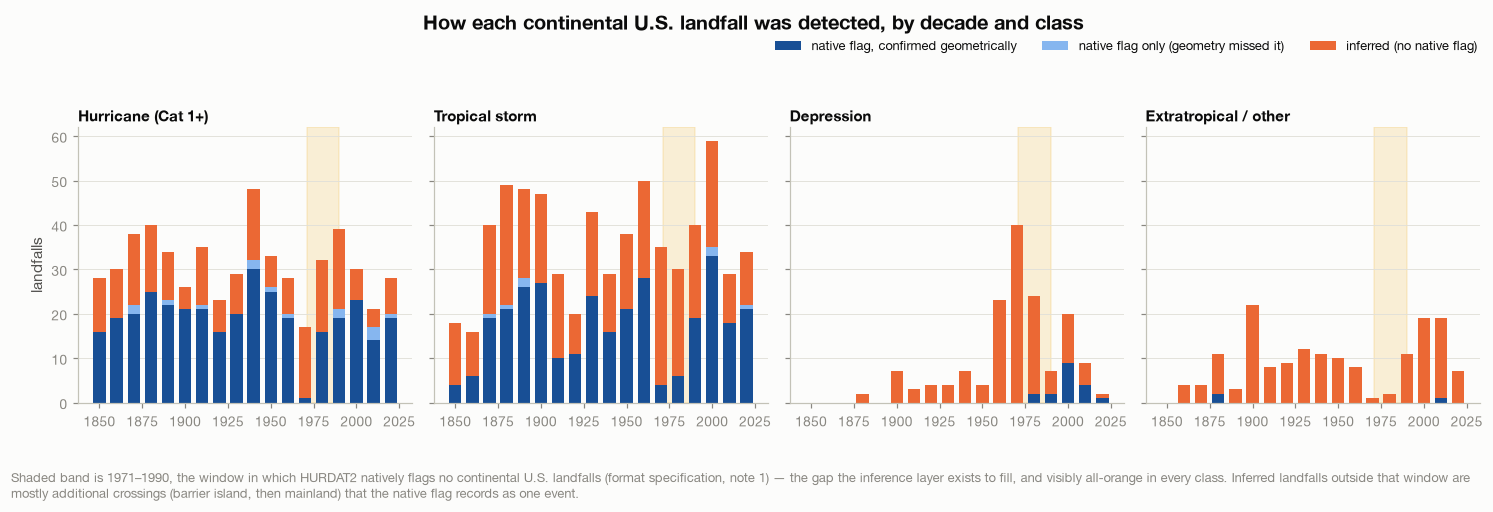

In [28]:
# How each landfall was found, by decade, faceted by event class.
METHODS = [("native_confirmed", "native flag, confirmed geometrically"),
           ("native", "native flag only (geometry missed it)"),
           ("inferred", "inferred (no native flag)")]
METHOD_COLOR = {"native_confirmed": "#184f95", "native": "#86b6ef",
                "inferred": ORANGE}

# NB: named detect_by_decade, not `prov` -- `prov` is the build-provenance
# Series from section 1 and is still needed further down.
detect_by_decade = (conus.assign(decade=(conus.season // 10) * 10)
                    .groupby(["event_class", "decade", "detection_method"],
                             observed=False)
                    .size().unstack(fill_value=0))
for col, _ in METHODS:
    if col not in detect_by_decade:
        detect_by_decade[col] = 0
display(conus.groupby(["event_class", "detection_method"], observed=False)
        .size().unstack(fill_value=0).reindex(CLASS_ORDER).fillna(0).astype(int))

panels = [c for c in CLASS_ORDER[:4]]
fig, axes = plt.subplots(1, 4, figsize=(13.5, 3.6), sharex=True, sharey=True)

for ax, cls in zip(axes, panels):
    sub = (detect_by_decade.loc[cls]
           if cls in detect_by_decade.index.get_level_values(0) else None)
    bottom = np.zeros(len(sub)) if sub is not None else None
    if sub is not None:
        for col, _label in METHODS:
            ax.bar(sub.index, sub[col], bottom=bottom, width=7.2,
                   color=METHOD_COLOR[col], linewidth=0)
            bottom += sub[col].values
    ax.set_title(cls, fontsize=10, loc="left", pad=4)
    # The documented native-flagging gap this layer exists to fill.
    ax.axvspan(1971, 1990, color="#eda100", alpha=0.15, zorder=0)
    tidy(ax)

axes[0].set_ylabel("landfalls")
from matplotlib.patches import Patch
fig.legend(handles=[Patch(facecolor=METHOD_COLOR[c], label=l) for c, l in METHODS],
           loc="upper right", ncols=3, bbox_to_anchor=(0.995, 1.06), fontsize=8.5)

fig.suptitle("How each continental U.S. landfall was detected, by decade and class",
             fontsize=13, fontweight="bold", color=INK, x=0.5, y=1.10)
caption(fig,
    "Shaded band is 1971–1990, the window in which HURDAT2 natively flags no "
    "continental U.S. landfalls (format specification, note 1) — the gap the "
    "inference layer exists to fill, and visibly all-orange in every class. "
    "Inferred landfalls outside that window are mostly additional crossings "
    "(barrier island, then mainland) that the native flag records as one event.",
    y=-0.06)
plt.tight_layout()
plt.show()

### What the record would look like on native flags alone

The comparison that motivates this whole layer. HURDAT2's `L` flag is
authoritative but, by its own documentation, incomplete: continental U.S.
landfalls are flagged only for 1851–1970 and 1991 onward. The figure below plots
the same per-class trends twice — once over every detected landfall, once over
only the natively-flagged subset — so the shortfall is visible directly rather
than asserted.

continental U.S. landfalls detected : 1,548
  of which natively flagged         : 702 (45%)
  found only by inference           : 846 (55%)

storms with a CONUS landfall        : 645
  visible via native flags          : 539
  visible ONLY by inference         : 106 (16%) — these storms would be absent from a native-flag-only landfall record entirely


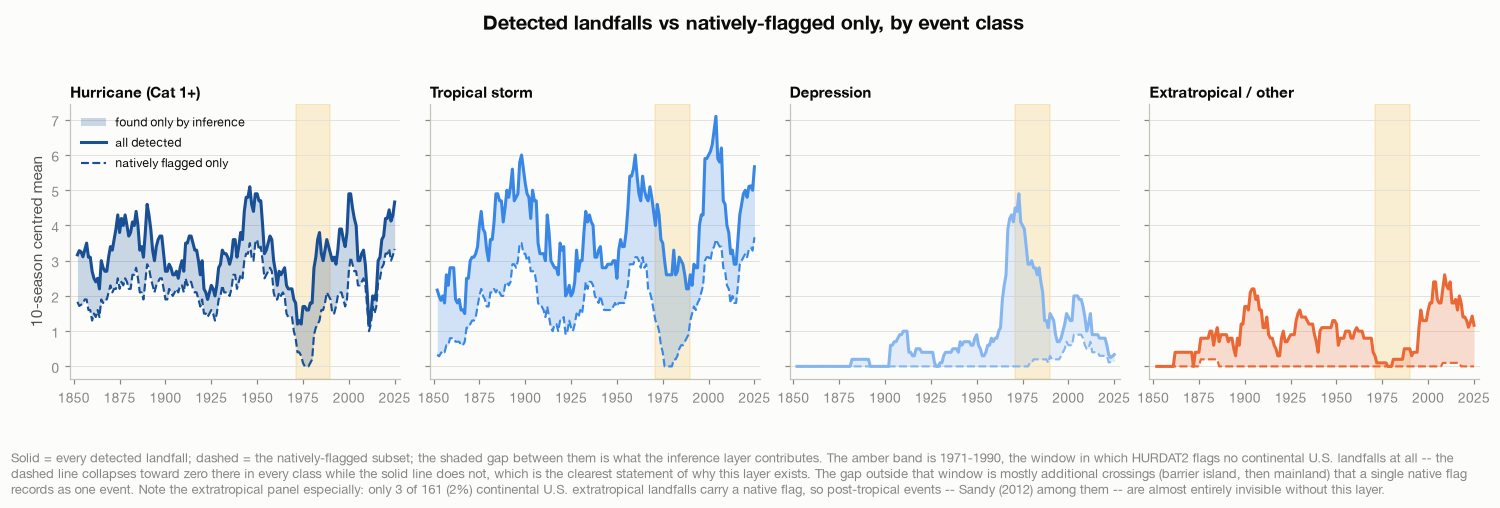

In [29]:
# Native-flagged subset vs everything detected, per class per season.
conus_native = conus[conus.detection_method.isin(['native', 'native_confirmed'])]

def class_season(frame):
    return (frame.groupby(['season', 'event_class'], observed=False).size()
            .unstack(fill_value=0)
            .reindex(index=years, fill_value=0)
            .reindex(columns=CLASS_ORDER, fill_value=0))

all_cs = class_season(conus)
nat_cs = class_season(conus_native)

# Headline arithmetic, computed rather than asserted.
n_all, n_nat = len(conus), len(conus_native)
storms_all = conus.storm_id.nunique()
storms_nat = conus_native.storm_id.nunique()
print(f'continental U.S. landfalls detected : {n_all:,}')
print(f'  of which natively flagged         : {n_nat:,} ({n_nat/n_all:.0%})')
print(f'  found only by inference           : {n_all-n_nat:,} ({1-n_nat/n_all:.0%})')
print()
print(f'storms with a CONUS landfall        : {storms_all:,}')
print(f'  visible via native flags          : {storms_nat:,}')
print(f'  visible ONLY by inference         : {storms_all-storms_nat:,} '
      f'({(storms_all-storms_nat)/storms_all:.0%}) — these storms would be absent '
      f'from a native-flag-only landfall record entirely')

panels = [c for c in CLASS_ORDER[:4] if all_cs[c].sum() > 0]
fig, axes = plt.subplots(1, len(panels), figsize=(13.5, 3.6),
                         sharex=True, sharey=True)
axes = np.atleast_1d(axes)

for ax, cls in zip(axes, panels):
    full = smoothed(all_cs[cls])
    nat = smoothed(nat_cs[cls])
    # The shaded gap between the two lines IS the inference layer's contribution.
    ax.fill_between(full.index, nat.values, full.values,
                    color=CLASS_COLOR[cls], alpha=0.22, linewidth=0,
                    label='found only by inference')
    ax.plot(full.index, full.values, color=CLASS_COLOR[cls], linewidth=2.0,
            label='all detected')
    ax.plot(nat.index, nat.values, color=CLASS_COLOR[cls], linewidth=1.4,
            linestyle='--', label='natively flagged only')

    # The documented native-flagging gap.
    ax.axvspan(1971, 1990, color='#eda100', alpha=0.16, zorder=0)
    ax.set_title(cls, fontsize=10, loc='left', pad=4)
    ax.set_xlim(1848, 2028)
    tidy(ax)

axes[0].set_ylabel(f'{SMOOTHING_SEASONS}-season centred mean')
axes[0].legend(loc='upper left', fontsize=8)

# The extratropical panel is the strongest single case, so quantify it rather
# than leaving the reader to infer it from the flat dashed line.
extra = conus[conus.event_class == CLS_EXTRA]
extra_native = int(extra.detection_method.isin(['native', 'native_confirmed']).sum())

fig.suptitle('Detected landfalls vs natively-flagged only, by event class',
             fontsize=13, fontweight='bold', color=INK, x=0.5, y=1.04)
caption(fig,
    'Solid = every detected landfall; dashed = the natively-flagged subset; the '
    'shaded gap between them is what the inference layer contributes. The amber '
    'band is 1971-1990, the window in which HURDAT2 flags no continental U.S. '
    'landfalls at all -- the dashed line collapses toward zero there in every '
    'class while the solid line does not, which is the clearest statement of why '
    'this layer exists. The gap outside that window is mostly additional crossings '
    '(barrier island, then mainland) that a single native flag records as one '
    'event. Note the extratropical panel especially: only '
    f'{extra_native} of {len(extra)} ({extra_native/len(extra):.0%}) continental U.S. '
    'extratropical landfalls carry a native flag, so post-tropical events -- Sandy '
    '(2012) among them -- are almost entirely invisible without this layer.',
    y=-0.07)
plt.tight_layout()
plt.show()

### The delta, season by season

How much the inference layer adds, and where. The delta is exact rather than
estimated: `detection_method` partitions every row, so
*detected − natively flagged* is precisely the count of `inferred` landfalls.

In [30]:
delta = pd.DataFrame({
    'detected': all_cs.sum(axis=1),
    'natively_flagged': nat_cs.sum(axis=1),
})
delta['delta'] = delta.detected - delta.natively_flagged
delta['delta_smoothed'] = smoothed(delta.delta)

# Summary by native-flagging era, straight from the HURDAT2 format spec.
def flagging_era(year):
    if year <= 1970:
        return '1851-1970\nflagged'
    if year <= 1990:
        return '1971-1990\nNOT flagged'
    return '1991-2025\nflagged'

era_index = pd.Index([flagging_era(y) for y in delta.index], name='era')
summary = delta.groupby(era_index).agg(
    seasons=('delta', 'size'),
    detected=('detected', 'sum'),
    natively_flagged=('natively_flagged', 'sum'),
    delta_total=('delta', 'sum'),
    delta_mean=('delta', 'mean'),
    delta_median=('delta', 'median'),
    delta_max=('delta', 'max'),
)
summary['% found by inference'] = (100 * summary.delta_total
                                   / summary.detected).round(1)
display(summary.round(2))

blind = int(((delta.natively_flagged == 0) & (delta.detected > 0)).sum())
print(f'seasons in which native flags alone would report ZERO continental U.S.')
print(f'landfalls, though landfalls did occur: {blind}')

,seasons,detected,natively_flagged,delta_total,delta_mean,delta_median,delta_max,% found by inference
era,,,,,,,,
1851-1970\nflagged,120,988,486,502,4.18,3.0,15,50.8
1971-1990\nNOT flagged,20,187,24,163,8.15,6.5,26,87.2
1991-2025\nflagged,35,373,192,181,5.17,4.0,24,48.5


seasons in which native flags alone would report ZERO continental U.S.
landfalls, though landfalls did occur: 14


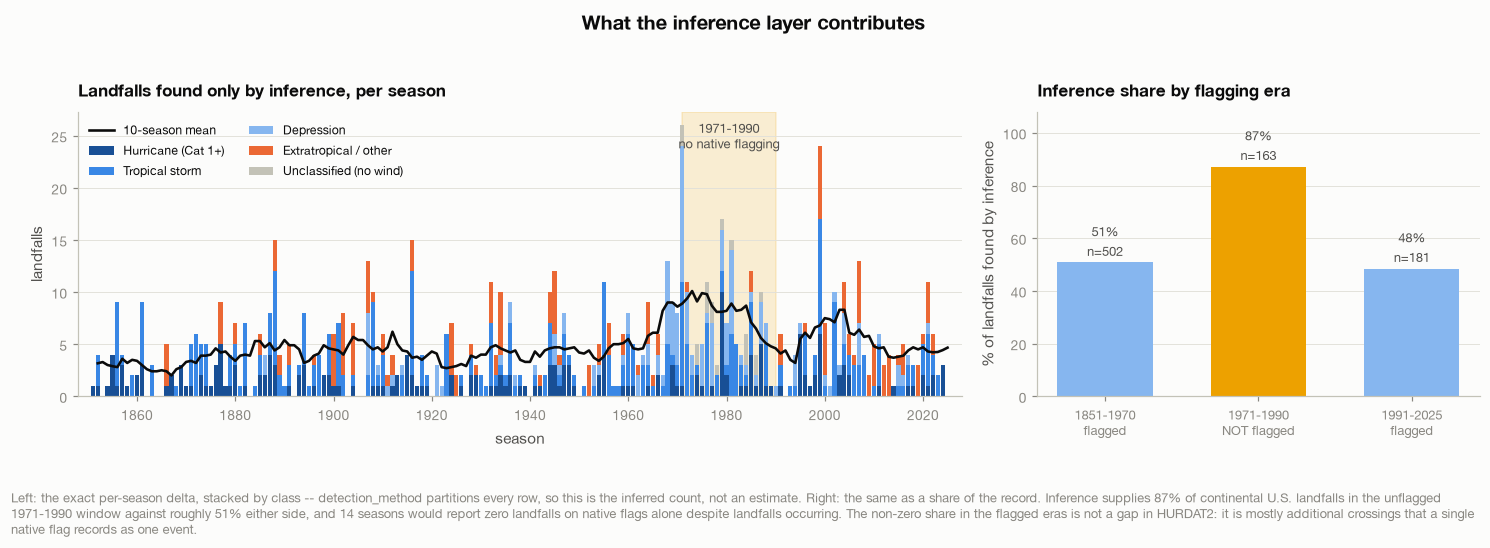

In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 4.0),
                               gridspec_kw={'width_ratios': [2, 1]})

# LEFT: the annual delta, stacked by class so the composition is visible.
delta_cs = all_cs - nat_cs
bottom = np.zeros(len(delta_cs))
for cls in CLASS_ORDER:
    if delta_cs[cls].sum() == 0:
        continue
    ax1.bar(delta_cs.index, delta_cs[cls], bottom=bottom, width=0.85,
            color=CLASS_COLOR[cls], linewidth=0, label=cls)
    bottom += delta_cs[cls].values
ax1.plot(delta.index, delta.delta_smoothed, color='#0b0b0b', linewidth=1.7,
         label=f'{SMOOTHING_SEASONS}-season mean')

ax1.axvspan(1971, 1990, color='#eda100', alpha=0.16, zorder=0)
ax1.text(1980.5, ax1.get_ylim()[1] * 0.97, '1971-1990\nno native flagging',
         ha='center', va='top', fontsize=8.5, color=INK_SECOND)
ax1.set_title('Landfalls found only by inference, per season',
              fontsize=11, loc='left')
ax1.set_ylabel('landfalls')
ax1.set_xlabel('season')
ax1.set_xlim(1848, 2028)
ax1.legend(loc='upper left', ncols=2, fontsize=8)
tidy(ax1)

# RIGHT: share of the record contributed by inference, by flagging era.
eras = list(summary.index)
vals = summary['% found by inference'].values
# Amber for the unflagged window, matching the shading used elsewhere; the two
# flagged eras share one neutral hue because they are the same condition.
colors = ['#86b6ef' if 'NOT' not in e else '#eda100' for e in eras]
ax2.bar(range(len(eras)), vals, width=0.62, color=colors, linewidth=0)
ax2.set_xticks(range(len(eras)))
ax2.set_xticklabels(eras, fontsize=8.5)
ax2.set_ylim(0, 108)
ax2.set_ylabel('% of landfalls found by inference')
ax2.set_title('Inference share by flagging era', fontsize=11, loc='left')
tidy(ax2)
for i, (v, n) in enumerate(zip(vals, summary.delta_total.values)):
    ax2.text(i, v + 2.5, f'{v:.0f}%\nn={int(n):,}', ha='center', fontsize=8.5,
             color=INK_SECOND, linespacing=1.3)

fig.suptitle('What the inference layer contributes',
             fontsize=13, fontweight='bold', color=INK, x=0.5, y=1.03)
caption(fig,
    f'Left: the exact per-season delta, stacked by class -- detection_method '
    f'partitions every row, so this is the inferred count, not an estimate. Right: '
    f'the same as a share of the record. Inference supplies {vals[1]:.0f}% of '
    f'continental U.S. landfalls in the unflagged 1971-1990 window against roughly '
    f'{vals[0]:.0f}% either side, and {blind} seasons would report zero landfalls '
    f'on native flags alone despite landfalls occurring. The non-zero share in the '
    f'flagged eras is not a gap in HURDAT2: it is mostly additional crossings that '
    f'a single native flag records as one event.', y=-0.06)
plt.tight_layout()
plt.show()

## 8. Why the geometry misses some native flags

Some landfalls carry a HURDAT2 `L` flag that the geometric pass did **not**
reproduce (`detection_method = 'native'`). Those rows are retained — the native
flag is authoritative and is never demoted — but it is worth knowing *why* the
geometry disagreed, because the answer says something about the coastline
input rather than about the detection rule.

Two candidate mechanisms are testable directly:

1. the NHC landfall position falls **outside the modelled land polygon**, so no
   water→land transition can exist there; or
2. the storm was **already ashore** at the preceding fix, so the crossing had
   already happened and NHC is flagging a second landfall the geometry sees as
   continuous overland travel.

In [32]:
# The pipeline records how far each landfall sits from the admin unit it was
# attributed to, so the diagnosis reads straight off the table -- no geometry
# needs recomputing here.
#
#   landfall_admin_distance_km = 0  -> the position lies INSIDE that unit
#   is_attribution_exact            -> the same fact as a boolean
#
# A geometric crossing is on the polygon boundary by construction, so it is
# always exact. Only native flags -- positions HURDAT2 supplies rather than the
# pipeline computing -- can fall outside the modelled coastline.
coast = gpd.read_parquet(BASEMAP)          # reused by the map in §11

by_method = landfalls.groupby("detection_method").agg(
    rows=("landfall_admin_distance_km", "size"),
    exact=("is_attribution_exact", "sum"),
    median_km=("landfall_admin_distance_km", "median"),
    p95_km=("landfall_admin_distance_km", lambda s: s.quantile(0.95)),
    max_km=("landfall_admin_distance_km", "max"),
)
by_method["inexact"] = by_method.rows - by_method.exact
by_method["% inexact"] = (100 * by_method.inexact / by_method.rows).round(2)
display(by_method[["rows", "exact", "inexact", "% inexact",
                   "median_km", "p95_km", "max_km"]].round(2))

inexact = landfalls[~landfalls.is_attribution_exact]
print(f"{len(inexact)} of {len(landfalls):,} landfall rows "
      f"({len(inexact)/len(landfalls):.2%}) are attributed by nearest neighbour "
      f"rather than containment.")
print(f"Every one of them is detection_method = "
      f"{sorted(inexact.detection_method.unique())} — which is structural, not "
      f"coincidence: a computed crossing cannot land off the coastline.")

,rows,exact,inexact,% inexact,median_km,p95_km,max_km
detection_method,,,,,,,
inferred,5311,5311,0,0.00,0.00,0.00,0.00
native,57,6,51,89.47,5.24,76.39,613.77
native_confirmed,1253,1253,0,0.00,0.00,0.00,0.00


51 of 6,621 landfall rows (0.77%) are attributed by nearest neighbour rather than containment.
Every one of them is detection_method = ['native'] — which is structural, not coincidence: a computed crossing cannot land off the coastline.


In [33]:
# MECHANISM 2 -- the native flags that ARE attributed exactly but were still not
# reproduced. These sit on land, so no water->land transition exists: the storm
# had already come ashore, and NHC is flagging a later landfall the geometry
# reads as continuous overland travel.
native_all = landfalls[landfalls.detection_method.isin(["native", "native_confirmed"])]
missed = native_all[native_all.detection_method == "native"]
reproduced = native_all[native_all.detection_method == "native_confirmed"]

on_land_missed = missed[missed.is_attribution_exact]
off_land_missed = missed[~missed.is_attribution_exact]

print(f"native flags total        : {len(native_all):,}")
print(f"  reproduced geometrically: {len(reproduced):,}")
print(f"  NOT reproduced          : {len(missed):,}  "
      f"({len(missed)/len(native_all):.1%})")
print()
print("MECHANISM 1 — flagged position lies outside the modelled coastline")
print(f"  {len(off_land_missed):>3d} of {len(missed)} "
      f"({len(off_land_missed)/len(missed):.0%})")
print()
print("MECHANISM 2 — position is on land, but the storm was already ashore")
print(f"  {len(on_land_missed):>3d} of {len(missed)} "
      f"({len(on_land_missed)/len(missed):.0%})")
print(f"  median landfall_seq {on_land_missed.landfall_seq.median():.0f} "
      f"vs {reproduced.landfall_seq.median():.0f} for reproduced flags — "
      f"i.e. these are later landfalls in the storm's sequence")

native flags total        : 1,310
  reproduced geometrically: 1,253
  NOT reproduced          : 57  (4.4%)

MECHANISM 1 — flagged position lies outside the modelled coastline
   51 of 57 (89%)

MECHANISM 2 — position is on land, but the storm was already ashore
    6 of 57 (11%)
  median landfall_seq 2 vs 2 for reproduced flags — i.e. these are later landfalls in the storm's sequence


missed  total  miss_rate_%
mainland event class                                      
False    Hurricane (Cat 1+)         32    324          9.9
         Tropical storm             14    240          5.8
         Depression                  0     20          0.0
         Extratropical / other       0      6          0.0
True     Hurricane (Cat 1+)          6    336          1.8
         Tropical storm              3    329          0.9
         Depression                  2     54          3.7
         Extratropical / other       0      1          0.0

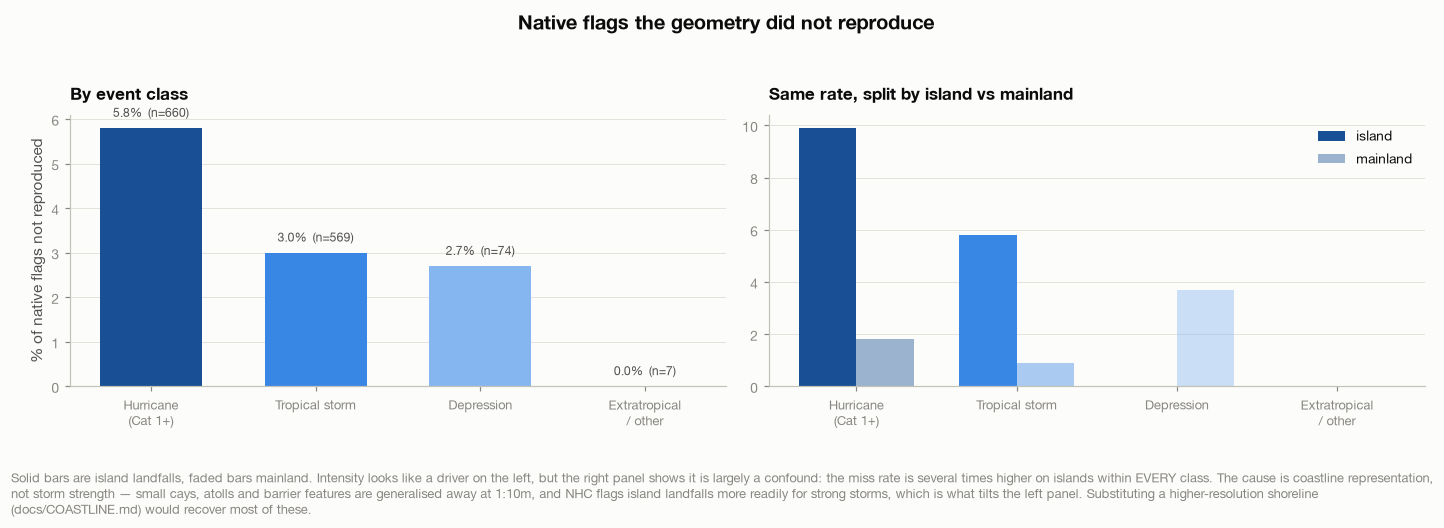

In [34]:
# Is intensity the driver, or is it location? Cross-tabulate the miss rate by
# event class AND by whether the land struck was the continental landmass.
native_all = native_all.assign(missed=native_all.detection_method == "native")
rate = (native_all.groupby(
            [native_all.is_mainland_landfall.astype(bool), "event_class"],
            observed=True)
        .missed.agg(missed="sum", total="count"))
rate["miss_rate_%"] = (100 * rate.missed / rate.total).round(1)
rate = rate[rate.total > 0].rename_axis(["mainland", "event class"])
display(rate)

by_class = (native_all.groupby("event_class", observed=True)
            .missed.agg(missed="sum", total="count"))
by_class["miss_rate_%"] = (100 * by_class.missed / by_class.total).round(1)
by_class = by_class[by_class.total > 0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 3.8))

# LEFT: miss rate by class -- the hypothesis the question started from.
classes = [c for c in CLASS_ORDER if c in by_class.index]
ax1.bar(range(len(classes)), [by_class.loc[c, "miss_rate_%"] for c in classes],
        color=[CLASS_COLOR[c] for c in classes], width=0.62, linewidth=0)
ax1.set_xticks(range(len(classes)))
ax1.set_xticklabels([c.replace(" (", "\n(").replace(" / ", "\n/ ") for c in classes],
                    fontsize=8.5)
ax1.set_ylabel("% of native flags not reproduced")
ax1.set_title("By event class", fontsize=11, loc="left")
tidy(ax1)
for i, c in enumerate(classes):
    ax1.text(i, by_class.loc[c, "miss_rate_%"] + 0.25,
             f"{by_class.loc[c, 'miss_rate_%']:.1f}%  (n={by_class.loc[c,'total']:,})",
             ha="center", fontsize=8, color=INK_SECOND)

# RIGHT: the same rate split by island vs mainland -- the confound.
width = 0.36
present = [c for c in CLASS_ORDER if (False, c) in rate.index or (True, c) in rate.index]
for offset, mainland, hatchless in [(-width/2, False, None), (width/2, True, None)]:
    vals = [rate.loc[(mainland, c), "miss_rate_%"] if (mainland, c) in rate.index else 0
            for c in present]
    ax2.bar(np.arange(len(present)) + offset, vals, width=width, linewidth=0,
            color=[CLASS_COLOR[c] for c in present],
            alpha=1.0 if not mainland else 0.42,
            label="island" if not mainland else "mainland")
ax2.set_xticks(range(len(present)))
ax2.set_xticklabels([c.replace(" (", "\n(").replace(" / ", "\n/ ") for c in present],
                    fontsize=8.5)
ax2.set_title("Same rate, split by island vs mainland", fontsize=11, loc="left")
ax2.legend(loc="upper right", fontsize=9)
tidy(ax2)

fig.suptitle("Native flags the geometry did not reproduce",
             fontsize=13, fontweight="bold", color=INK, x=0.5, y=1.04)
caption(fig,
    "Solid bars are island landfalls, faded bars mainland. Intensity looks like a "
    "driver on the left, but the right panel shows it is largely a confound: the "
    "miss rate is several times higher on islands within EVERY class. The cause is "
    "coastline representation, not storm strength — small cays, atolls and barrier "
    "features are generalised away at 1:10m, and NHC flags island landfalls more "
    "readily for strong storms, which is what tilts the left panel. Substituting a "
    "higher-resolution shoreline (docs/COASTLINE.md) would recover most of these.",
    y=-0.06)
plt.tight_layout()
plt.show()

In [35]:
# The clearest evidence: how far offshore the un-reproduced flags sit. HURDAT2
# records positions to 0.1 degree, which is ~11.1 km of latitude -- so a flag
# within that distance of its attributed unit is consistent with nothing worse
# than position rounding meeting a generalised shoreline.
offshore = off_land_missed

# One HURDAT2 position quantum as a distance: positions are recorded to 0.1
# degree, and one degree of latitude is 111.19 km on WGS-84. Both figures come
# from the source format and the ellipsoid, not from a choice.
QUANTUM_KM = 0.1 * 111.19

print("distance from un-reproduced flag to the unit it was attributed to (km):")
print(offshore.landfall_admin_distance_km
      .describe()[["min", "25%", "50%", "75%", "max"]].round(1).to_string())
print(f"\nwithin one HURDAT2 position quantum ({QUANTUM_KM:.1f} km): "
      f"{(offshore.landfall_admin_distance_km <= QUANTUM_KM).sum()}"
      f"/{len(offshore)} "
      f"({(offshore.landfall_admin_distance_km <= QUANTUM_KM).mean():.0%})")

print("\nFurthest cases — small islands absent from a 1:10m coastline:")
# Round only the numeric columns: a blanket .round() warns on the datetime.
display(offshore.nlargest(6, "landfall_admin_distance_km")[
    ["storm_id", "exact_time", "landfall_admin1", "landfall_country",
     "exact_wind_kt", "event_class", "landfall_admin_distance_km"]]
    .round({"landfall_admin_distance_km": 1, "exact_wind_kt": 0}))

print("\nMost of these labels are CORRECT — the Dry Tortugas really are Florida")
print("and French Frigate Shoals really is Hawaii; the coastline simply omits")
print("them. That is why the distance is RECORDED rather than thresholded: a")
print("cutoff tight enough to reject a genuinely wrong label would discard more")
print("correct ones than it saved. Use is_attribution_exact to keep only")
print("containment-based attributions, or filter the distance yourself.")

distance from un-reproduced flag to the unit it was attributed to (km):
min      0.2
25%      3.1
50%      6.4
75%     16.8
max    613.8

within one HURDAT2 position quantum (11.1 km): 33/51 (65%)

Furthest cases — small islands absent from a 1:10m coastline:


,storm_id,exact_time,landfall_admin1,landfall_country,exact_wind_kt,event_class,landfall_admin_distance_km
3523,AL071963,1963-10-10 06:00:00+00:00,Southampton,Bermuda,95.0,Hurricane (Cat 1+),613.8
6552,CP012018,2018-10-04 06:20:00+00:00,Hawaii,United States of America,110.0,Hurricane (Cat 1+),157.0
1883,AL021919,1919-09-10 07:00:00+00:00,Florida,United States of America,130.0,Hurricane (Cat 1+),76.4
2742,AL131944,1944-10-18 21:00:00+00:00,Florida,United States of America,105.0,Hurricane (Cat 1+),76.4
6024,AL092022,2022-09-28 02:00:00+00:00,Florida,United States of America,110.0,Hurricane (Cat 1+),76.4
257,AL091870,1870-10-20 14:00:00+00:00,Florida,United States of America,80.0,Hurricane (Cat 1+),67.3



Most of these labels are CORRECT — the Dry Tortugas really are Florida
and French Frigate Shoals really is Hawaii; the coastline simply omits
them. That is why the distance is RECORDED rather than thresholded: a
cutoff tight enough to reject a genuinely wrong label would discard more
correct ones than it saved. Use is_attribution_exact to keep only
containment-based attributions, or filter the distance yourself.


### Attribution quality: programmatic vs native, side by side

The figure that makes the difference between the two detection routes obvious.
Programmatic (geometric) landfalls are attributed by **containment** — the
crossing point lies on the polygon, so the distance is exactly zero and there is
nothing to judge. Native flags are positions HURDAT2 supplies, so they can land
where this coastline has no polygon; their distance measures how far the
attribution had to reach.

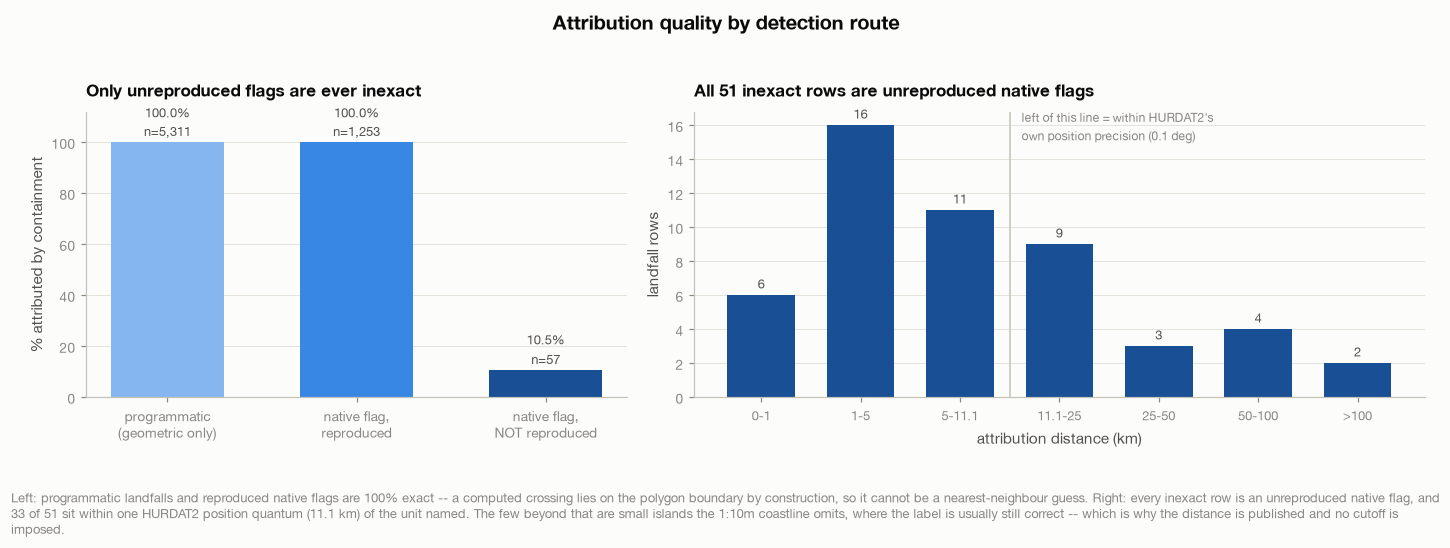

In [36]:
ROUTE_LABELS = {
    'inferred':         'programmatic\n(geometric only)',
    'native_confirmed': 'native flag,\nreproduced',
    'native':           'native flag,\nNOT reproduced',
}
ROUTE_ORDER = ['inferred', 'native_confirmed', 'native']
# Ordered by how far the attribution had to reach, so a single-hue ordinal ramp
# is the right encoding: light = always exact, dark = the route that can miss.
ROUTE_COLOR = {'inferred': '#86b6ef', 'native_confirmed': '#3987e5',
               'native': '#184f95'}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.0),
                               gridspec_kw={'width_ratios': [1, 1.35]})

# LEFT: what fraction of each route is attributed by containment.
shares, labels, totals = [], [], []
for route in ROUTE_ORDER:
    sub = landfalls[landfalls.detection_method == route]
    shares.append(100 * sub.is_attribution_exact.mean())
    labels.append(ROUTE_LABELS[route])
    totals.append(len(sub))

ax1.bar(range(len(ROUTE_ORDER)), shares, width=0.6, linewidth=0,
        color=[ROUTE_COLOR[r] for r in ROUTE_ORDER])
ax1.set_xticks(range(len(ROUTE_ORDER)))
ax1.set_xticklabels(labels, fontsize=9)
ax1.set_ylabel('% attributed by containment')
ax1.set_ylim(0, 112)
ax1.set_title('Only unreproduced flags are ever inexact', fontsize=11, loc='left')
tidy(ax1)
for i, (share, total) in enumerate(zip(shares, totals)):
    ax1.text(i, share + 2.5, f'{share:.1f}%\nn={total:,}', ha='center',
             fontsize=8.5, color=INK_SECOND, linespacing=1.3)

# RIGHT: where the non-zero distances fall. Only unreproduced native flags
# contribute -- the other two routes have nothing to draw, which is the point.
nonzero = landfalls[landfalls.landfall_admin_distance_km > 0]
edges = [0, 1, 5, QUANTUM_KM, 25, 50, 100, 1000]
bin_labels = ['0-1', '1-5', f'5-{QUANTUM_KM:.1f}', f'{QUANTUM_KM:.1f}-25',
              '25-50', '50-100', '>100']
counts = (pd.cut(nonzero.landfall_admin_distance_km, bins=edges,
                 labels=bin_labels)
          .value_counts().reindex(bin_labels).fillna(0))

ax2.bar(range(len(bin_labels)), counts.values, width=0.68, linewidth=0,
        color=ROUTE_COLOR['native'])
ax2.set_xticks(range(len(bin_labels)))
ax2.set_xticklabels(bin_labels, fontsize=8.5)
ax2.set_xlabel('attribution distance (km)')
ax2.set_ylabel('landfall rows')
ax2.set_title(f'All {len(nonzero)} inexact rows are unreproduced native flags',
              fontsize=11, loc='left')
tidy(ax2)
for i, v in enumerate(counts.values):
    if v:
        ax2.text(i, v + 0.4, f'{int(v)}', ha='center', fontsize=8.5,
                 color=INK_SECOND)

# Bin edge at 11.1 km is HURDAT2's own position quantum, not a chosen cutoff.
ax2.axvline(2.5, color=AXIS, linewidth=1)
ax2.text(2.62, ax2.get_ylim()[1] * 0.90,
         "left of this line = within HURDAT2's\nown position precision (0.1 deg)",
         fontsize=8, color=INK_MUTED, linespacing=1.4)

within = int((nonzero.landfall_admin_distance_km <= QUANTUM_KM).sum())
fig.suptitle('Attribution quality by detection route',
             fontsize=13, fontweight='bold', color=INK, x=0.5, y=1.03)
caption(fig,
    'Left: programmatic landfalls and reproduced native flags are 100% exact -- a '
    'computed crossing lies on the polygon boundary by construction, so it cannot '
    'be a nearest-neighbour guess. Right: every inexact row is an unreproduced '
    f'native flag, and {within} of {len(nonzero)} sit within one HURDAT2 position '
    'quantum (11.1 km) of the unit named. The few beyond that are small islands '
    'the 1:10m coastline omits, where the label is usually still correct -- which '
    'is why the distance is published and no cutoff is imposed.', y=-0.06)
plt.tight_layout()
plt.show()

## 9. Timing — exact vs 6-hourly intensity

For storms intensifying up to the coast, *which* time is called "landfall"
changes the intensity attributed to it. The schema stores both and privileges
neither.

In [37]:
# Compare intensity at the exact crossing against the preceding synoptic fix.
timing = conus.dropna(subset=["exact_wind_kt", "sixhr_wind_kt"]).copy()
timing["delta_kt"] = timing.exact_wind_kt - timing.sixhr_wind_kt

differ = (timing.delta_kt != 0).sum()
print(f"landfalls with both intensities recorded : {len(timing):,}")
print(f"  where the two differ                    : {differ:,} ({differ/len(timing):.0%})")
print(f"  exact stronger than 6-hourly            : {(timing.delta_kt > 0).sum():,}")
print(f"  exact weaker than 6-hourly              : {(timing.delta_kt < 0).sum():,}")
print(f"  largest intensification into landfall   : +{timing.delta_kt.max():.0f} kt")

display(timing.nlargest(6, "delta_kt")[
    ["name", "season", "landfall_admin1", "sixhr_wind_kt",
     "exact_wind_kt", "delta_kt", "hours_from_6hr_to_landfall"]]
    .reset_index(drop=True))

landfalls with both intensities recorded : 1,530
  where the two differ                    : 563 (37%)
  exact stronger than 6-hourly            : 134
  exact weaker than 6-hourly              : 429
  largest intensification into landfall   : +15 kt


,name,season,landfall_admin1,sixhr_wind_kt,exact_wind_kt,delta_kt,hours_from_6hr_to_landfall
0,UNNAMED,1898,Florida,55,70.0,15.0,4.962121
1,UNNAMED,1898,Florida,55,70.0,15.0,5.533333
2,ANDREW,1992,Florida,130,145.0,15.0,2.666667
3,ANDREW,1992,Florida,130,145.0,15.0,3.210145
4,GORDON,2018,Florida,30,45.0,15.0,5.343750
5,MICHAEL,2018,Florida,125,140.0,15.0,5.419118


,n,% intensity differs,median |delta| kt,max strengthening kt
class,,,,
Hurricane (Cat 1+),559,35.2,0.0,15.0
Tropical storm,654,36.5,0.0,15.0
Depression,156,35.9,0.0,6.0
Extratropical / other,161,44.1,0.0,11.0


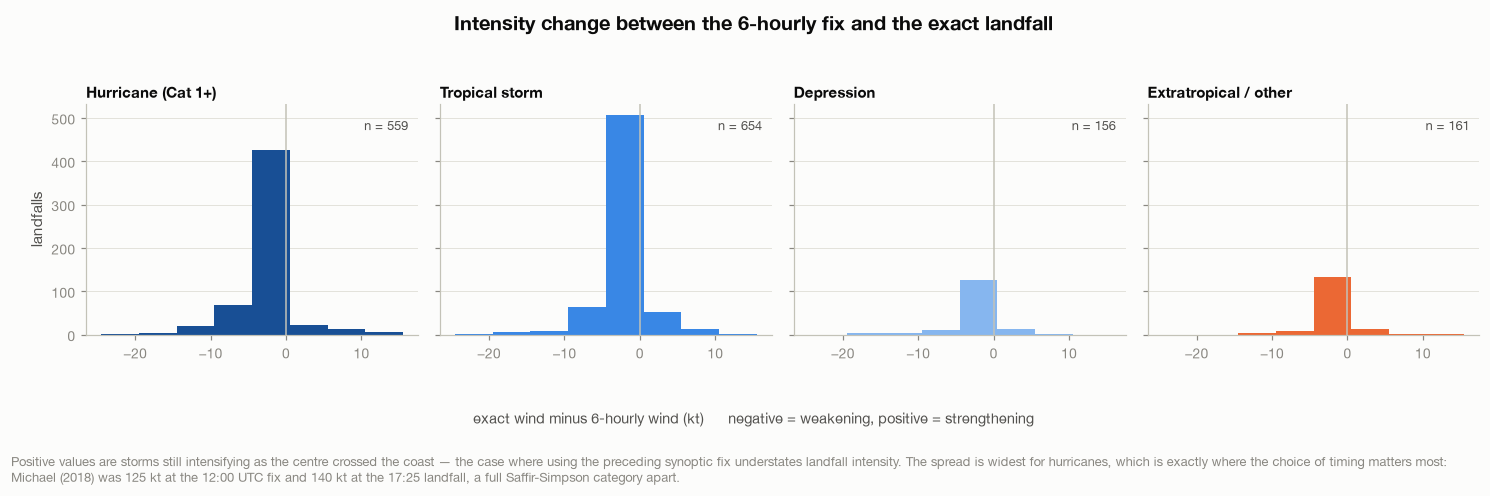

In [38]:
panels = [c for c in CLASS_ORDER[:4] if (timing.event_class == c).any()]
fig, axes = plt.subplots(1, len(panels), figsize=(13.5, 3.5),
                         sharex=True, sharey=True)
axes = np.atleast_1d(axes)

bins = np.arange(timing.delta_kt.min() - 2.5, timing.delta_kt.max() + 5, 5)
summary = []
for ax, cls in zip(axes, panels):
    sub = timing[timing.event_class == cls]
    ax.hist(sub.delta_kt, bins=bins, color=CLASS_COLOR[cls], linewidth=0)
    ax.axvline(0, color=AXIS, linewidth=1)
    ax.set_title(cls, fontsize=10, loc="left", pad=4)
    changed = (sub.delta_kt != 0).mean() if len(sub) else np.nan
    summary.append({"class": cls, "n": len(sub),
                    "% intensity differs": round(100 * changed, 1),
                    "median |delta| kt": sub.delta_kt.abs().median(),
                    "max strengthening kt": sub.delta_kt.max()})
    ax.text(0.97, 0.94, f"n = {len(sub):,}", transform=ax.transAxes,
            ha="right", va="top", fontsize=8.5, color=INK_SECOND)
    tidy(ax)

axes[0].set_ylabel("landfalls")
fig.supxlabel("exact wind minus 6-hourly wind (kt)"
              "      negative = weakening, positive = strengthening",
              fontsize=9.5, color=INK_SECOND, y=-0.04)

display(pd.DataFrame(summary).set_index("class"))

fig.suptitle("Intensity change between the 6-hourly fix and the exact landfall",
             fontsize=13, fontweight="bold", color=INK, x=0.5, y=1.04)
caption(fig,
    "Positive values are storms still intensifying as the centre crossed the coast — "
    "the case where using the preceding synoptic fix understates landfall intensity. "
    "The spread is widest for hurricanes, which is exactly where the choice of timing "
    "matters most: Michael (2018) was 125 kt at the 12:00 UTC fix and 140 kt at the "
    "17:25 landfall, a full Saffir-Simpson category apart.", y=-0.11)
plt.tight_layout()
plt.show()

## 10. Distance to coast and near-misses

In [39]:
# min_distance_to_coast_km is populated on every track point, so the bypass
# radius shipped with the build is only a label -- any threshold can be applied
# after the fact without re-running the pipeline. Demonstrated here.
closest = points.groupby("storm_id").min_distance_to_coast_km.min()
landfalling = set(landfalls.loc[landfalls.is_landfall, "storm_id"])
near = closest[~closest.index.isin(landfalling)]

thresholds = [50, 111.12, 200, 300, 500]
table = pd.DataFrame({
    "radius_km": thresholds,
    "non_landfalling_storms_within": [int((near <= t).sum()) for t in thresholds],
})
table["pct_of_non_landfalling"] = (100 * table.non_landfalling_storms_within
                                   / len(near)).round(1)
display(table)
print(f"shipped bypass radius = {float(prov['calibration.bypass_radius_km']):.2f} km "
      f"→ {len(bypasses):,} bypass storms in the built table")

,radius_km,non_landfalling_storms_within,pct_of_non_landfalling
0,50.00,315,17.5
1,111.12,684,38.0
2,200.00,986,54.7
3,300.00,1209,67.1
4,500.00,1469,81.5


shipped bypass radius = 111.12 km → 684 bypass storms in the built table


,non-landfalling storms,within 111 km (bypass)
event_class,,
Hurricane (Cat 1+),765,322
Tropical storm,802,296
Depression,235,66
Extratropical / other,0,0
Unclassified (no wind),0,0


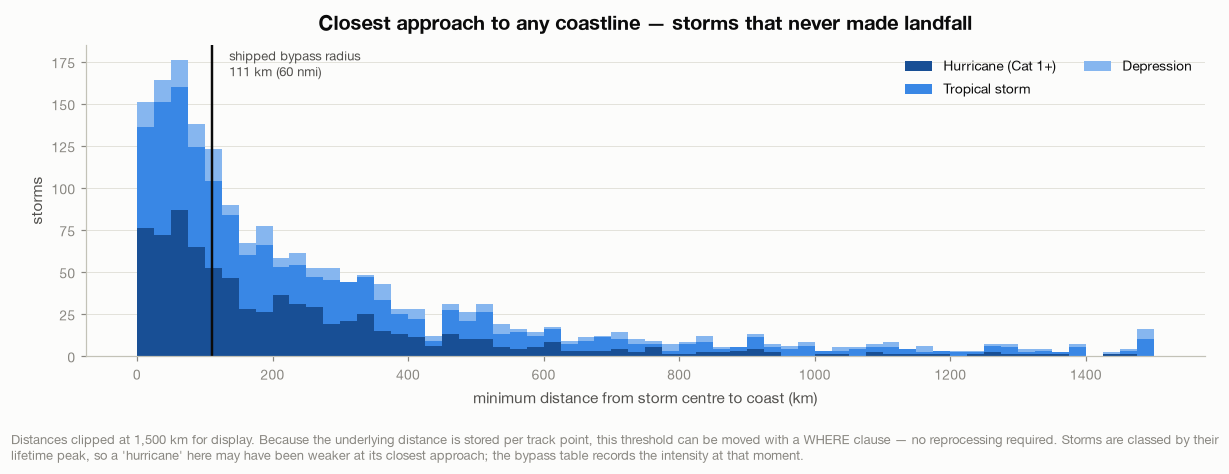

In [40]:
# Attach each non-landfalling storm's lifetime class to its closest approach.
near_df = near.rename("closest_km").to_frame()
near_df["event_class"] = pd.Categorical(
    near_df.index.map(storms.set_index("storm_id").event_class),
    categories=CLASS_ORDER, ordered=True)

fig, ax = plt.subplots(figsize=(11, 3.9))

# Stacked histogram: the classes partition the same set of storms, so the stack
# height is the count in each distance bin.
bins = np.linspace(0, 1500, 61)
present = [c for c in CLASS_ORDER if (near_df.event_class == c).any()]
ax.hist([near_df.loc[near_df.event_class == c, "closest_km"].clip(upper=1500)
         for c in present],
        bins=bins, stacked=True, linewidth=0,
        color=[CLASS_COLOR[c] for c in present], label=present)

ax.set_title("Closest approach to any coastline — storms that never made landfall")
ax.set_xlabel("minimum distance from storm centre to coast (km)")
ax.set_ylabel("storms")
tidy(ax)

# Mark the shipped radius; it is a labelling choice, not a data boundary.
radius = float(prov["calibration.bypass_radius_km"])
ax.axvline(radius, color="#0b0b0b", linewidth=1.6)
ax.text(radius + 25, ax.get_ylim()[1] * 0.90,
        f"shipped bypass radius\n{radius:.0f} km (60 nmi)",
        fontsize=8.5, color=INK_SECOND)
class_legend(ax, present, loc="upper right", ncols=2)

within = near_df[near_df.closest_km <= radius]
display(pd.DataFrame({
    "non-landfalling storms": near_df.event_class.value_counts(),
    f"within {radius:.0f} km (bypass)": within.event_class.value_counts(),
}).reindex(CLASS_ORDER).fillna(0).astype(int))

caption(fig, "Distances clipped at 1,500 km for display. Because the underlying "
             "distance is stored per track point, this threshold can be moved with a "
             "WHERE clause — no reprocessing required. Storms are classed by their "
             "lifetime peak, so a 'hurricane' here may have been weaker at its closest "
             "approach; the bypass table records the intensity at that moment.")
plt.tight_layout()
plt.show()

## 11. Where landfalls happen

In [41]:
# Landfall positions are plain columns (exact_lon / exact_lat), so the CONUS
# frame already assembled above is all the point data the map needs.
#
# The backdrop comes from a small committed extract of the Natural Earth
# coastline (data/reference/, ~145 KB, built by scripts/make_basemap.py). It is
# clipped and simplified for DISPLAY ONLY -- landfall detection always uses the
# full-precision coastline configured in config/pipeline.yaml, never this file.
print(f"{len(conus):,} continental U.S. landfall points to plot")
print(f"basemap: {len(coast)} display polygons "
      f"({BASEMAP.stat().st_size / 1024:.0f} KB)")

1,548 continental U.S. landfall points to plot
basemap: 102 display polygons (145 KB)


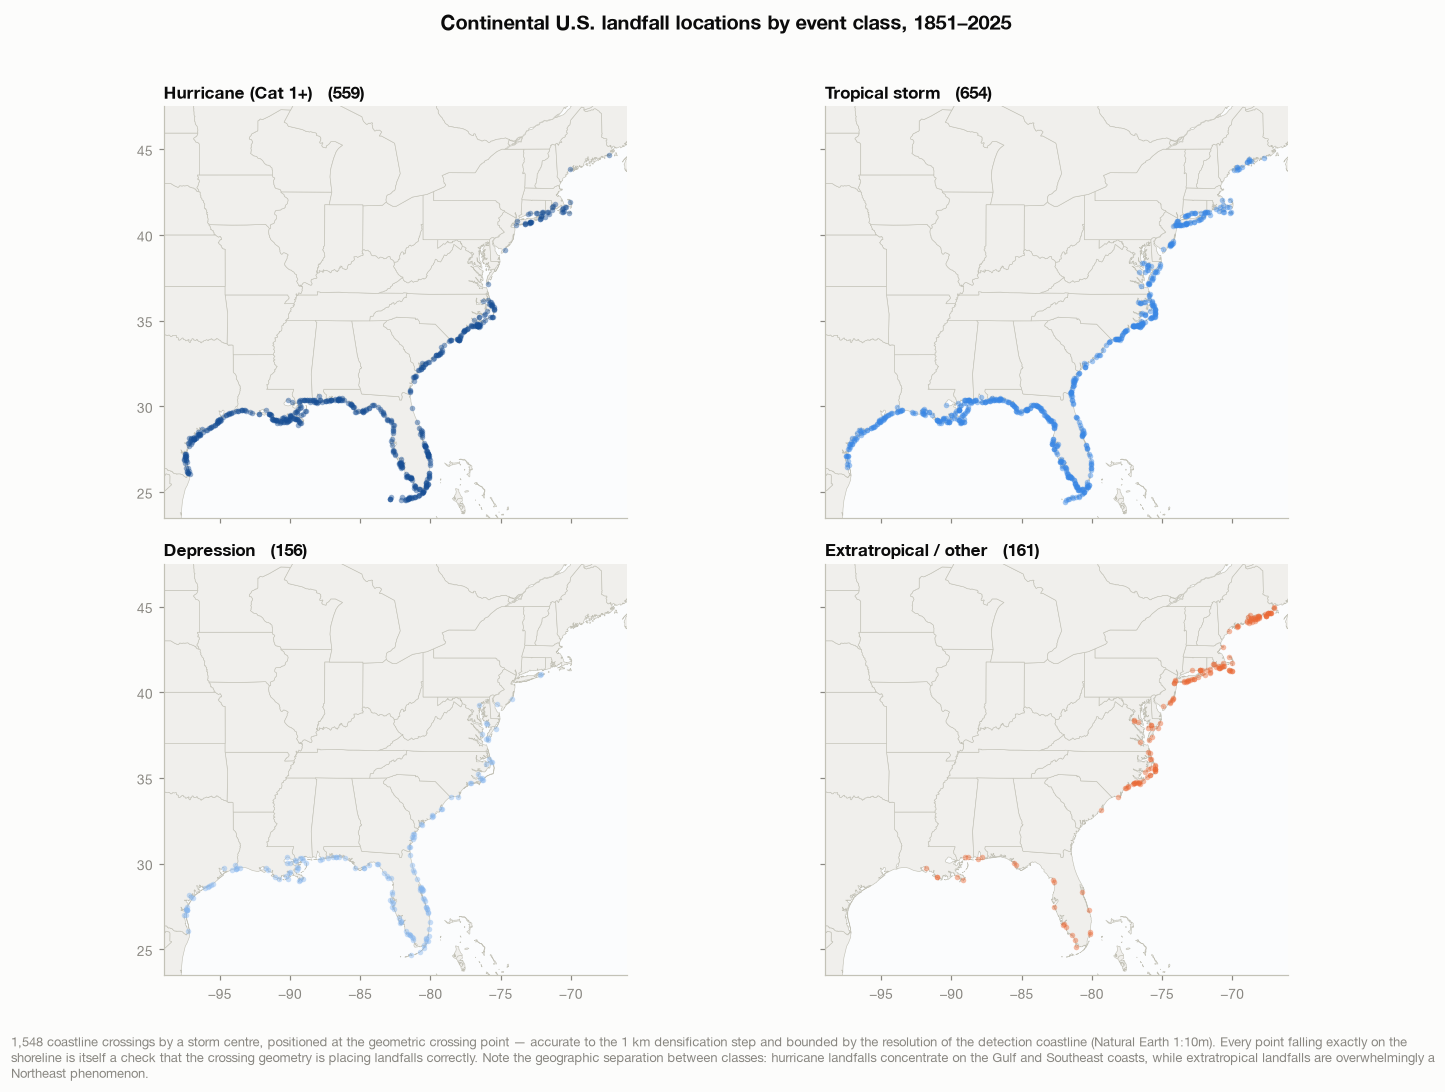

In [42]:
# Faceted rather than colour-coded: a dense scatter cannot carry four hues
# reliably, and overplotting would hide whichever class is drawn first.
panels = [c for c in CLASS_ORDER[:4] if (conus.event_class == c).any()]
fig, axes = plt.subplots(2, 2, figsize=(13, 9.4), sharex=True, sharey=True)
axes = axes.ravel()

for ax, cls in zip(axes, panels):
    sub = conus[conus.event_class == cls]

    # Land as a recessive backdrop; the landfall points are the data. Every
    # panel draws the full outline so the panels stay directly comparable.
    coast.plot(ax=ax, facecolor="#f0efec", edgecolor=AXIS, linewidth=0.4)
    ax.scatter(sub.exact_lon, sub.exact_lat,
               s=13, color=CLASS_COLOR[cls], alpha=0.45, linewidth=0, zorder=3)

    ax.set_title(f"{cls}   ({len(sub):,})", fontsize=11, loc="left", pad=5)
    ax.set_xlim(-99, -66)
    ax.set_ylim(23.5, 47.5)
    # Plotting lon/lat on equal axes stretches the map vertically, because a
    # degree of longitude is shorter than a degree of latitude away from the
    # equator. Scaling by 1/cos(mid-latitude) restores true local proportions.
    ax.set_aspect(1 / np.cos(np.radians(35)))
    ax.set_facecolor("#fbfcfd")     # a hint of water behind the land
    ax.grid(False)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)

for ax in axes[len(panels):]:
    ax.set_visible(False)

fig.suptitle("Continental U.S. landfall locations by event class, 1851–2025",
             fontsize=13, fontweight="bold", color=INK, x=0.5, y=0.995)
caption(fig, f"{len(conus):,} coastline crossings by a storm centre, positioned at the "
             "geometric crossing point — accurate to the 1 km densification step and "
             "bounded by the resolution of the detection coastline (Natural Earth "
             "1:10m). Every point falling exactly on the shoreline is itself a check "
             "that the crossing geometry is placing landfalls correctly. Note the "
             "geographic separation between classes: hurricane landfalls concentrate "
             "on the Gulf and Southeast coasts, while extratropical landfalls are "
             "overwhelmingly a Northeast phenomenon.", y=0.005)
plt.tight_layout(rect=[0, 0.02, 1, 0.98])
plt.show()

## Summary

**Validation.** All structural checks pass: keys are unique, referential
integrity holds, parsed track-point counts match the HURDAT2 headers exactly,
no missing-data sentinels survive as numbers, every categorical value is
spec-valid, and no native landfall flag was demoted by the inference layer.

**What the data will and will not support.**

- `min_distance_to_coast_km` is populated on all track points, so any coastal
  proximity threshold can be applied after the fact.
- Landfall counts are counts of **crossings**, not storms — a barrier-island
  strike followed by a mainland strike is two rows. Both figures are available.
- Exact and 6-hourly landfall intensities differ for a large share of events;
  which one to use is an analytical choice the schema deliberately leaves open.
- **Long-run landfall trends are not physical.** Pre-1944 counts are biased low
  by missed storms and under-analysed intensities. Any trend claim must be
  restricted to the satellite era or explicitly corrected for detection bias.

**Provenance.** Every figure here traces to `pipeline_metadata`, which records
the source files and checksums, the coastline, the gate set, and each
calibration value with its status and source.